# import packages

In [5]:
import os
os.environ['KMP_DUPLICATE_LIB_OK']='True'

In [6]:
#!pip install torchdiffeq

In [7]:
# import packages
import os
import argparse
import logging
import time
import numpy as np
import numpy.random as npr
import matplotlib
# matplotlib.use('agg')
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import math
import random

from datetime import timedelta
import scipy.stats
from sklearn.decomposition import PCA
from torch.utils.data import Dataset, DataLoader

import copy

from scipy.interpolate import splev, splrep, interp1d

import sklearn
from sklearn.neighbors import NearestNeighbors

from prettytable import PrettyTable

from torchdiffeq import odeint_adjoint as odeint_adjoint
from torchdiffeq import odeint

In [10]:
import numpy as np
import torch


def create_adap_data_buffer(window, ts, thres, num_fine_grid, num_layers_adap,
                            buffer_start_steps=2, obs_dim=2, verbose=0, return_index=0):
    """
    create_adap_data_buffer: Dyadic algorithm for selecting adaptive steps to create irregular mesh

    :window: a batch of time series sequences to be processed, could be multi-dimensional. The shape is (bacth_size, window_length, obs_dim).
            The type is torch.tensor
    :ts: the corresponding time stamps. The shape is (bacth_size, window_length). The type is torch.tensor
    :thres: the threshold epsilon that determines which time steps are to be selected. Larger thres leads to fewer steps. thres is a scalar.
    :num_fine_grid: the number of finest grids of the windows
    :num_layers_adap: the number of maximum iterations of the adaptive selection process. num_layers_adap is an integer >= 1.
    :buffer_start_steps: the number of buffer steps to be added before each window. buffer_start_steps is an integer >= 0.
    :obs_dim: the dimension of the data
    :verbose: an integer that determines whether to print the information
    :return_index: an integer that decides whether the remaining indexes are to be kept

    :return: returns the list consisting of data and time stamps after adaptive selection
    """

    train_windows_adap1 = []  # selected data
    train_ts_adap1 = []  # selected time stamps
    train_len_adap1 = []  # remaining length
    time_ind_remain1 = []  # remaining index

    t_ind_list = np.arange(num_fine_grid + 1)
    num_shrink = (window.shape[1] - 1) // num_fine_grid
    # -----------------------------------------------------------------------------------
    for i in range(window.shape[0]):  # process each window separately

        index_temp = np.zeros((ts.shape[1],))

        train_data_temp = window[i, ::num_shrink, :]
        train_ts_temp = ts[i, ::num_shrink]

        time_steps_delete = []  # the set of time stamps to be remove

        for layer in range(num_layers_adap - 1):  # for each layer
            len_temp = 2 ** (layer + 1)
            if layer == 0:
                train_data_temp_diff = np.diff(train_data_temp, axis=0)
                train_data_temp_diff = np.sqrt(np.sum(train_data_temp_diff ** 2, axis=1))
                train_data_temp_diff = train_data_temp_diff / np.diff(train_ts_temp)
                # compute the variation in each finest subinterval (in l_2 norm).
                # the variation can be chosen case by case

            if layer >= 1:
                time_keep_flag_cur = time_keep_flag
                # an indicator of whether each point was kept in the last round

            num_grid_temp = num_fine_grid // 2 ** (layer + 1)
            time_keep_flag = np.ones((num_grid_temp,))
            # an indicator of whether each point will be kept in the new round

            for j in range(num_grid_temp):
                if layer == 0:
                    if max(train_data_temp_diff[len_temp * j:len_temp * (j + 1)]) <= thres:
                        time_keep_flag[j] = 0
                        time_steps_delete.append(len_temp * j + len_temp // 2)
                else:
                    if time_keep_flag_cur[2 * j] + time_keep_flag_cur[2 * j + 1] == 0:
                        train_data_temp_diff1 = np.diff(
                            train_data_temp[len_temp * j:len_temp * (j + 1) + 1:len_temp // 2], axis=0)
                        train_data_temp_diff1 = np.sqrt(np.sum(train_data_temp_diff1 ** 2, axis=1))
                        train_data_temp_diff1 = train_data_temp_diff1 / np.diff(
                            train_ts_temp[len_temp * j:len_temp * (j + 1) + 1:len_temp // 2])

                        if train_data_temp_diff1.max() <= thres:
                            time_keep_flag[j] = 0
                            time_steps_delete.append(len_temp * j + len_temp // 2)

        time_steps_remain = np.delete(t_ind_list, time_steps_delete)  # the indexes to be kept
        train_len_adap1.append(time_steps_remain.shape[0])
        train_ts_adap1.append(train_ts_temp[time_steps_remain])
        train_windows_adap1.append(train_data_temp[time_steps_remain, :])
        if return_index:
            time_ind_remain_temp = time_steps_remain * num_shrink
            index_temp[time_ind_remain_temp] = 1
            time_ind_remain1.append(index_temp)

    # -----------------------------------------------------------------------------------
    # padding, so that the output sequences have the same length
    for i in range(window.shape[0]):
        train_data_temp = train_windows_adap1[i]
        train_ts_temp = train_ts_adap1[i]
        num_temp = max(train_len_adap1) - train_data_temp.shape[0]
        train_ts_temp = torch.cat((train_ts_temp, train_ts_temp[-1].repeat(num_temp)))
        train_data_temp = torch.cat((train_data_temp, train_data_temp[-1, :].reshape((1, obs_dim)).repeat(num_temp, 1)))

        train_windows_adap1[i] = train_data_temp
        train_ts_adap1[i] = train_ts_temp

    train_windows_adap1 = torch.stack(train_windows_adap1)
    train_ts_adap1 = torch.stack(train_ts_adap1)

    # -----------------------------------------------------------------------------------
    # add buffer zone to adaptively selected windows
    train_windows_adap1_buffer = torch.zeros((train_windows_adap1.shape[0],
                                              train_windows_adap1.shape[1] + buffer_start_steps, obs_dim))
    train_ts_adap1_buffer = torch.zeros((train_windows_adap1.shape[0],
                                         train_windows_adap1.shape[1] + buffer_start_steps))
    train_len_adap1_buffer = [0] * train_windows_adap1.shape[0]
    for i in range(train_windows_adap1.shape[0]):
        train_windows_adap1_buffer[i, :, :] = torch.cat(
            (train_windows_adap1[i, 0, :].reshape(1, obs_dim).repeat(buffer_start_steps, 1),
             train_windows_adap1[i, :, :]))
        train_len_adap1_buffer[i] = train_len_adap1[i] + buffer_start_steps

    train_ts_adap1_buffer[:, buffer_start_steps:] = train_ts_adap1
    deltat = ts[0][1] - ts[0][0]
    train_ts_adap1_buffer[:, :buffer_start_steps] = (
            train_ts_adap1[:, 0].reshape(train_ts_adap1.shape[0], 1).repeat(1, buffer_start_steps)
            + torch.linspace(-deltat * buffer_start_steps, -deltat, buffer_start_steps))
    # -----------------------------------------------------------------------------------
    if verbose:
        print('thres = %.2f, averaged window length of adaptive data = %.1f' % (thres, np.mean(train_len_adap1)))

    if return_index:
        return train_windows_adap1_buffer, train_ts_adap1_buffer, train_len_adap1_buffer, np.mean(
            train_len_adap1), np.stack(time_ind_remain1)
    else:
        return train_windows_adap1_buffer, train_ts_adap1_buffer, train_len_adap1_buffer, np.mean(train_len_adap1)

In [12]:
import torch
from scipy.interpolate import interp1d

def interpolate_window(window, ts, ts0, interp_kind, obs_dim=2):
    window0 = torch.zeros(window.shape[0], ts0.shape[1], window.shape[2])
    for i in range(window.shape[0]):
        xk = ts[i, :]
        x2 = ts0[i, :]
        for k in range(obs_dim):
            yk = window[i, :, k]
            f = interp1d(xk, yk, kind=interp_kind)
            window0[i, :, k] = torch.tensor(f(x2))
    return window0


def interpolate_window_adap(window, ts, window_len, ts0, interp_kind, obs_dim=2):
    window0 = torch.zeros(window.shape[0], ts0.shape[1], window.shape[2])
    for i in range(window.shape[0]):
        xk = ts[i, :window_len[i]]
        x2 = ts0[i, :]
        for k in range(obs_dim):
            yk = window[i, :window_len[i], k]
            f = interp1d(xk, yk, kind=interp_kind)
            window0[i, :, k] = torch.tensor(f(x2))
    return window0

In [15]:
import torch
import torch.nn as nn

class RNNODE(nn.Module):
    def __init__(self, input_dim=1, n_latent=128, n_hidden=128):
        super(RNNODE, self).__init__()
        self.fc1 = nn.Linear(input_dim + n_latent, n_hidden)
        self.tanh = nn.Tanh()

    def forward(self, t, h, x):
        out = self.fc1(torch.cat((x, h), dim=1))
        out = self.tanh(out)
        return out

    def initHidden(self):
        return


class OutputNN(nn.Module):
    def __init__(self, input_dim=2, n_latent=128):
        super(OutputNN, self).__init__()
        self.fc = nn.Linear(n_latent, input_dim)
        self.sigmoid = nn.Sigmoid()
        self.n_latent = n_latent

    def forward(self, h):
        out = self.fc(h)
        return out


class RNN(nn.Module):
    def __init__(self, input_dim=2, n_latent=128):
        super(RNN, self).__init__()
        self.rnn = nn.RNN(input_size=input_dim, hidden_size=n_latent, batch_first=True)
        self.linear = nn.Linear(n_latent, input_dim)

    def forward(self, x, h_0):
        x = x.reshape(x.shape[0], 1, x.shape[1])
        h_0 = h_0.reshape(1, h_0.shape[0], h_0.shape[1])

        _, final_hidden_state = self.rnn(x, h_0)
        output = self.linear(final_hidden_state)

        return output.reshape(output.shape[1], output.shape[2]), final_hidden_state.reshape(h_0.shape[1], h_0.shape[2])


class LSTM(nn.Module):
    def __init__(self, input_dim=2, n_latent=128):
        super(LSTM, self).__init__()
        self.lstm = nn.LSTM(input_size=input_dim, hidden_size=n_latent, batch_first=True)
        self.linear = nn.Linear(n_latent, input_dim)

    def forward(self, x, h_0, c_0):
        x = x.reshape(x.shape[0], 1, x.shape[1])
        #         print(x.shape)
        h_0 = h_0.reshape(1, h_0.shape[0], h_0.shape[1])
        c_0 = c_0.reshape(1, c_0.shape[0], c_0.shape[1])

        output, (final_hidden_state, final_cell_state) = self.lstm(x, (h_0, c_0))
        output = self.linear(output)

        #         print(output.shape)
        output = output.reshape(output.shape[0], output.shape[2])
        final_hidden_state = final_hidden_state.reshape(h_0.shape[1], h_0.shape[2])
        final_cell_state = final_cell_state.reshape(c_0.shape[1], c_0.shape[2])

        return output, final_hidden_state, final_cell_state

In [16]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import time
import matplotlib.pyplot as plt
from scipy.interpolate import splev, splrep, interp1d
from datetime import timedelta
#from interpolate_windows import interpolate_window
#from NN import LSTM


def fit_LSTM_grids(lstm, window_orig, ts_orig, num_grids,
                   interp_kind='cubic', buffer_start_steps=2, verbose=1, n_latent=128, obs_dim=2):
    # index contains the buffer steps
    test_ts2 = torch.tensor(np.linspace(ts_orig[:, 0], ts_orig[:, -1], num_grids).T)
    test_ts2 = torch.concat((test_ts2[:, 0].reshape(test_ts2.shape[0], 1).repeat(1, buffer_start_steps),
                             test_ts2), dim=1)

    test_windows2 = interpolate_window(window_orig, ts_orig, test_ts2, 'cubic')

    if buffer_start_steps > 0:
        deltat = test_ts2[0][-1] - test_ts2[0][-2]
        test_ts2[:, :buffer_start_steps] = (test_ts2[:, :buffer_start_steps] +
                                            torch.arange(-deltat * buffer_start_steps, 0, deltat))

    input_len = test_windows2.shape[1]

    with torch.no_grad():
        h0 = torch.zeros(window_orig.shape[0], n_latent)
        c0 = torch.zeros(window_orig.shape[0], n_latent)
        xhat_window_test2 = []
        xhat_window_test2.append(test_windows2[:, 0, :].numpy())
        for t_ind in range(input_len - 1):
            x_temp = test_windows2[:, t_ind, :]
            xhat, h1, c1 = lstm(x_temp, h0, c0)
            xhat_window_test2.append(xhat.detach().numpy())
            h0 = h1
            c0 = c1

    xhat_window_test2 = np.transpose(np.array(xhat_window_test2), (1, 0, 2))

    xhat_window_test2_temp = np.zeros((xhat_window_test2.shape[0], window_orig.shape[1] - 1, obs_dim))
    for i in range(window_orig.shape[0]):
        xk = test_ts2[i, :]
        x2 = ts_orig[i, :]
        for k in range(obs_dim):
            yk = xhat_window_test2[i, :, k]
            f = interp1d(xk, yk, kind=interp_kind)
            xhat_window_test2_temp[i, :, k] = torch.tensor(f(x2))[1:]
    xhat_window_test2 = xhat_window_test2_temp

    # compute errors

    fit_L2_err_test2 = torch.mean(torch.sum((window_orig[:, 1:, :] - xhat_window_test2) ** 2
                                            , dim=(2)), dim=1) ** 0.5  # /xhat_window_test2.shape[1]
    fit_L1_err_test2 = torch.mean(torch.sum((window_orig[:, 1:, :] - xhat_window_test2) ** 2
                                            , dim=(2)) ** 0.5, dim=1)
    if verbose:
        print('L1 err = %.3e \pm %.3e, L2 err = %.3e \pm %.3e' %
              (fit_L1_err_test2.mean(), fit_L1_err_test2.std(),
               fit_L2_err_test2.mean(), fit_L2_err_test2.std()))

    return xhat_window_test2, fit_L2_err_test2, fit_L1_err_test2


def pred_LSTM_grids(lstm, window_orig, ts_orig, num_grids, interp_kind='cubic',
                    buffer_start_steps=2, verbose=1, n_latent=128, obs_dim=2):
    test_ts2 = torch.tensor(np.linspace(ts_orig[:, 0], ts_orig[:, -1], num_grids).T)
    test_ts2 = torch.concat((test_ts2[:, 0].reshape(test_ts2.shape[0], 1).repeat(1, buffer_start_steps),
                             test_ts2), dim=1)

    test_windows2 = interpolate_window(window_orig, ts_orig, test_ts2, 'cubic')

    if buffer_start_steps > 0:
        deltat = test_ts2[0][-1] - test_ts2[0][-2]
        test_ts2[:, :buffer_start_steps] = (test_ts2[:, :buffer_start_steps] +
                                            torch.arange(-deltat * buffer_start_steps, 0, deltat))

    input_len = (num_grids + 1) // 2 + buffer_start_steps
    pred_len = (num_grids - 1) // 2

    with torch.no_grad():
        h0 = torch.zeros(window_orig.shape[0], n_latent)
        c0 = torch.zeros(window_orig.shape[0], n_latent)
        xhat_window_test2 = []
        pred_window_test2 = []
        xhat_window_test2.append(test_windows2[:, 0, :].numpy())
        for t_ind in range(input_len - 1):
            x_temp = test_windows2[:, t_ind, :]
            xhat, h1, c1 = lstm(x_temp, h0, c0)
            xhat_window_test2.append(xhat.detach().numpy())
            h0 = h1
            c0 = c1

        pred_window_test2.append(test_windows2[:, t_ind, :].numpy())
        for t_ind in range((input_len - 1), (input_len - 1) + pred_len):
            #             if t_ind == input_len-1:
            #                 x_temp = test_windows2[:,t_ind,:]
            #             else:
            #                 x_temp = xhat.detach()
            x_temp = xhat.detach()
            xhat, h1, c1 = lstm(x_temp, h0, c0)
            pred_window_test2.append(xhat.detach().numpy())
            h0 = h1
            c0 = c1

    xhat_window_test2 = np.transpose(np.array(xhat_window_test2), (1, 0, 2))[:, buffer_start_steps:, :]
    pred_window_test2 = np.transpose(np.array(pred_window_test2), (1, 0, 2))
    #     print(xhat_window_test2.shape, pred_window_test2.shape)

    pred_window_test2_temp = np.zeros((pred_window_test2.shape[0], (ts_orig.shape[1] - 1) // 2, obs_dim))
    for i in range(window_orig.shape[0]):
        xk = test_ts2[i, input_len - 1:]
        x2 = ts_orig[i, (ts_orig.shape[1] + 1) // 2:]
        for k in range(pred_window_test2.shape[2]):
            yk = pred_window_test2[i, :, k]
            f = interp1d(xk, yk, kind=interp_kind)
            pred_window_test2_temp[i, :, k] = torch.tensor(f(x2))  # [1:]
    pred_window_test2 = pred_window_test2_temp

    # compute errors

    pred_L2_err_test2 = torch.mean(torch.sum((window_orig[:, -(ts_orig.shape[1] - 1) // 2:, :] - pred_window_test2) ** 2
                                             , dim=(2)), dim=1) ** 0.5
    pred_L1_err_test2 = torch.mean(torch.sum((window_orig[:, -(ts_orig.shape[1] - 1) // 2:, :] - pred_window_test2) ** 2
                                             , dim=(2)) ** 0.5, dim=1)

    if verbose:
        print('L1 err = %.3e \pm %.3e, L2 err = %.3e \pm %.3e' %
              (pred_L1_err_test2.mean(), pred_L1_err_test2.std(),
               pred_L2_err_test2.mean(), pred_L2_err_test2.std()))

    return xhat_window_test2, pred_window_test2, pred_L2_err_test2, pred_L1_err_test2

def train_LSTM(train_dataloader, input_steps, valid_window, valid_ts, num_grids,
                verbose, lr=1e-2, n_iter=400, n_latent=128, num_train_windows=500,
                obs_dim=2, thres1=1e3, thres2=5e1, buffer_start_steps=2, time_scale=10):
    lstm = LSTM(input_dim=obs_dim, n_latent=n_latent)
    params = list(lstm.parameters())
    opt = optim.Adam(params, lr=lr)
    train_loss = []
    fit_err = []
    min_valid_loss = 1e5

    t1 = time.time()
    for itr in range(1, n_iter+ 1):
        # for itr in range(1,11):
        loss_epoch = 0.
        for batch_idx, samples in enumerate(train_dataloader):

            samples, train_ts_temp = samples[0], samples[1]
            h0 = torch.zeros(samples.shape[0], n_latent)
            c0 = torch.zeros(samples.shape[0], n_latent)
            loss = torch.tensor(0.0, dtype=torch.float, requires_grad=True)
            opt.zero_grad()
            for t_ind in range(input_steps - 1):
                x_temp = samples[:, t_ind, :]
                deltat_mult = (train_ts_temp[:, t_ind + 1] - train_ts_temp[:, t_ind])
                xhat, h1, c1 = lstm(x_temp, h0, c0)
                loss = loss + torch.sum((xhat - samples[:, t_ind + 1, :]) ** 2
                                        * deltat_mult.reshape(samples.shape[0], 1).repeat(1, obs_dim)) / time_scale
                h0 = h1
                c0 = c1

            loss_epoch += loss.item()
            loss.backward()
            opt.step()

        _, _, valid_loss, _ = pred_LSTM_grids(lstm, valid_window, valid_ts, num_grids,
                                              buffer_start_steps=buffer_start_steps, verbose=0, n_latent=n_latent)
        valid_loss = valid_loss.mean()
        fit_err.append(valid_loss)
        if valid_loss < min_valid_loss:
            torch.save(lstm, 'saved_model1.pth')
            min_valid_loss = valid_loss

        t2 = time.time()
        remain_time = (t2 - t1) / itr * (n_iter - itr)
        train_loss.append(loss_epoch / num_train_windows)
        if verbose >= 2:
            print('the %d-th epoch, training loss = %.4e' % (itr, loss_epoch / num_train_windows)
                  + ', remaining time = ' + str(timedelta(seconds=remain_time)))
        elif verbose == 1 and (itr == n_iter or itr == 1):
            print('the %d-th epoch, training loss = %.4e' % (itr, loss_epoch / num_train_windows)
                  + ', remaining time = ' + str(timedelta(seconds=remain_time)))
        if loss_epoch / num_train_windows >= thres1 or (
                itr >= 10 and loss_epoch / num_train_windows >= thres2):
            return False, lstm

    t3 = time.time()
    plt.plot(train_loss)
    plt.show()
    plt.plot(fit_err)
    plt.title('validation error')
    lstm = torch.load('saved_model1.pth')
    _, _, valid_loss, _ = pred_LSTM_grids(lstm, valid_window, valid_ts, num_grids,
                                          buffer_start_steps=buffer_start_steps, verbose=0, n_latent=n_latent)
    valid_loss = valid_loss.mean()
    plt.axhline(valid_loss, color='red', linestyle='--')
    plt.show()

    print('Training Neural ODE takes %.2f s' % (t3 - t1))

    return True, lstm

In [17]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import time
import matplotlib.pyplot as plt
from scipy.interpolate import splev, splrep, interp1d
from datetime import timedelta



def fit_RNN_grids(rnn, window_orig, ts_orig, num_grids,
                  interp_kind='cubic', buffer_start_steps=2, verbose=1, n_latent=128, obs_dim=2):
    # index contains the buffer steps
    test_ts2 = torch.tensor(np.linspace(ts_orig[:, 0], ts_orig[:, -1], num_grids).T)
    test_ts2 = torch.concat((test_ts2[:, 0].reshape(test_ts2.shape[0], 1).repeat(1, buffer_start_steps),
                             test_ts2), axis=1)

    test_windows2 = interpolate_window(window_orig, ts_orig, test_ts2, 'cubic')

    if buffer_start_steps > 0:
        deltat = test_ts2[0][-1] - test_ts2[0][-2]
        test_ts2[:, :buffer_start_steps] = (test_ts2[:, :buffer_start_steps] +
                                            torch.arange(-deltat * buffer_start_steps, 0, deltat))

    input_len = test_windows2.shape[1]

    with torch.no_grad():
        h0 = torch.zeros(window_orig.shape[0], n_latent)
        xhat_window_test2 = []
        xhat_window_test2.append(test_windows2[:, 0, :].numpy())
        for t_ind in range(input_len - 1):
            x_temp = test_windows2[:, t_ind, :]
            xhat, h1 = rnn(x_temp, h0)
            xhat_window_test2.append(xhat.detach().numpy())
            h0 = h1

    xhat_window_test2 = np.transpose(np.array(xhat_window_test2), (1, 0, 2))

    xhat_window_test2_temp = np.zeros((xhat_window_test2.shape[0], window_orig.shape[1] - 1, obs_dim))
    for i in range(window_orig.shape[0]):
        xk = test_ts2[i, :]
        x2 = ts_orig[i, :]
        for k in range(obs_dim):
            yk = xhat_window_test2[i, :, k]
            f = interp1d(xk, yk, kind=interp_kind)
            xhat_window_test2_temp[i, :, k] = torch.tensor(f(x2))[1:]
    xhat_window_test2 = xhat_window_test2_temp

    # compute errors

    fit_L2_err_test2 = torch.mean(torch.sum((window_orig[:, 1:, :] - xhat_window_test2) ** 2
                                            , dim=(2)), dim=1) ** 0.5  # /xhat_window_test2.shape[1]
    fit_L1_err_test2 = torch.mean(torch.sum((window_orig[:, 1:, :] - xhat_window_test2) ** 2
                                            , dim=(2)) ** 0.5, dim=1)

    if verbose:
        print('L1 err = %.3e \pm %.3e, L2 err = %.3e \pm %.3e' %
              (fit_L1_err_test2.mean(), fit_L1_err_test2.std(),
               fit_L2_err_test2.mean(), fit_L2_err_test2.std()))

    return xhat_window_test2, fit_L2_err_test2, fit_L1_err_test2


def pred_RNN_grids(rnn, window_orig, ts_orig, num_grids, interp_kind='cubic',
                   buffer_start_steps=2, verbose=1, n_latent=128, obs_dim=2):
    test_ts2 = torch.tensor(np.linspace(ts_orig[:, 0], ts_orig[:, -1], num_grids).T)
    test_ts2 = torch.concat((test_ts2[:, 0].reshape(test_ts2.shape[0], 1).repeat(1, buffer_start_steps),
                             test_ts2), dim=1)

    test_windows2 = interpolate_window(window_orig, ts_orig, test_ts2, 'cubic')

    if buffer_start_steps > 0:
        deltat = test_ts2[0][-1] - test_ts2[0][-2]
        test_ts2[:, :buffer_start_steps] = (test_ts2[:, :buffer_start_steps] +
                                            torch.arange(-deltat * buffer_start_steps, 0, deltat))

    input_len = (num_grids + 1) // 2 + buffer_start_steps
    pred_len = (num_grids - 1) // 2

    with torch.no_grad():
        h0 = torch.zeros(window_orig.shape[0], n_latent)
        xhat_window_test2 = []
        pred_window_test2 = []
        xhat_window_test2.append(test_windows2[:, 0, :].numpy())
        for t_ind in range(input_len - 1):
            x_temp = test_windows2[:, t_ind, :]
            xhat, h1 = rnn(x_temp, h0)
            xhat_window_test2.append(xhat.detach().numpy())
            h0 = h1

        pred_window_test2.append(test_windows2[:, t_ind, :].numpy())
        for t_ind in range((input_len - 1), (input_len - 1) + pred_len):
            if t_ind == input_len - 1:
                x_temp = test_windows2[:, t_ind, :]
            else:
                x_temp = xhat.detach()
            xhat, h1 = rnn(x_temp, h0)
            pred_window_test2.append(xhat.detach().numpy())
            h0 = h1

    xhat_window_test2 = np.transpose(np.array(xhat_window_test2), (1, 0, 2))[:, buffer_start_steps:, :]
    pred_window_test2 = np.transpose(np.array(pred_window_test2), (1, 0, 2))
    #     print(xhat_window_test2.shape, pred_window_test2.shape)

    pred_window_test2_temp = np.zeros((pred_window_test2.shape[0], (ts_orig.shape[1] - 1) // 2, obs_dim))
    for i in range(window_orig.shape[0]):
        xk = test_ts2[i, input_len - 1:]
        x2 = ts_orig[i, (ts_orig.shape[1] + 1) // 2:]
        #         print(xk, x2)
        for k in range(pred_window_test2.shape[2]):
            yk = pred_window_test2[i, :, k]
            #             print(xk.shape, x2.shape, yk.shape)
            f = interp1d(xk, yk, kind=interp_kind)
            pred_window_test2_temp[i, :, k] = torch.tensor(f(x2))  # [1:]
    pred_window_test2 = pred_window_test2_temp

    # compute errors

    pred_L2_err_test2 = torch.mean(torch.sum((window_orig[:, -(ts_orig.shape[1] - 1) // 2:, :] - pred_window_test2) ** 2
                                             , dim=(2)), dim=1) ** 0.5
    pred_L1_err_test2 = torch.mean(torch.sum((window_orig[:, -(ts_orig.shape[1] - 1) // 2:, :] - pred_window_test2) ** 2
                                             , dim=(2)) ** 0.5, dim=1)
    if verbose:
        print('L1 err = %.3e \pm %.3e, L2 err = %.3e \pm %.3e' %
              (pred_L1_err_test2.mean(), pred_L1_err_test2.std(),
               pred_L2_err_test2.mean(), pred_L2_err_test2.std()))

    return xhat_window_test2, pred_window_test2, pred_L2_err_test2, pred_L1_err_test2


def train_RNN(train_dataloader, input_steps, valid_window, valid_ts, num_grids,
               verbose, lr=1e-2, n_iter=400, n_latent=128, num_train_windows=500,
               obs_dim=2, thres1=1e3, thres2=5e1, buffer_start_steps=2, time_scale=10):
    rnn = RNN(input_dim=obs_dim, n_latent=n_latent)
    params = list(rnn.parameters())
    opt = optim.Adam(params, lr=lr)
    train_loss = []
    fit_err = []
    min_valid_loss = 1e5

    t1 = time.time()
    for itr in range(1, n_iter + 1):
        # for itr in range(1,11):
        loss_epoch = 0.
        for batch_idx, samples in enumerate(train_dataloader):

            samples, train_ts_temp = samples[0], samples[1]
            h0 = torch.zeros(samples.shape[0], n_latent)
            loss = torch.tensor(0.0, dtype=torch.float, requires_grad=True)
            opt.zero_grad()
            for t_ind in range(input_steps - 1):
                x_temp = samples[:, t_ind, :]
                deltat_mult = (train_ts_temp[:, t_ind + 1] - train_ts_temp[:, t_ind])
                xhat, h1 = rnn(x_temp, h0)
                #                 print(xhat.shape)
                loss = loss + torch.sum((xhat - samples[:, t_ind + 1, :]) ** 2
                                        * deltat_mult.reshape(samples.shape[0], 1).repeat(1, obs_dim)) / time_scale
                h0 = h1

            loss_epoch += loss.item()
            loss.backward()
            opt.step()

        _, _, valid_loss, _ = pred_RNN_grids(rnn, valid_window, valid_ts, num_grids,
                                             buffer_start_steps=buffer_start_steps, verbose=0)
        valid_loss = valid_loss.mean()
        fit_err.append(valid_loss)
        if valid_loss < min_valid_loss:
            torch.save(rnn, 'saved_model.pth')
            min_valid_loss = valid_loss

        t2 = time.time()
        remain_time = (t2 - t1) / itr * (n_iter - itr)
        train_loss.append(loss_epoch / num_train_windows)
        if verbose >= 2:
            print('the %d-th epoch, training loss = %.4e' % (itr, loss_epoch / num_train_windows)
                  + ', remaining time = ' + str(timedelta(seconds=remain_time)))
        elif verbose == 1 and (itr == n_iter or itr == 1):
            print('the %d-th epoch, training loss = %.4e' % (itr, loss_epoch / num_train_windows)
                  + ', remaining time = ' + str(timedelta(seconds=remain_time)))
        if loss_epoch / num_train_windows >= thres1 or (
                itr >= 10 and loss_epoch / num_train_windows >= thres2):
            return False, rnn

    t3 = time.time()
    plt.plot(train_loss)
    plt.show()

    plt.plot(fit_err)
    plt.title('validation error')
    rnn = torch.load('saved_model.pth')
    _, _, valid_loss, _ = pred_RNN_grids(rnn, valid_window, valid_ts, num_grids,
                                         buffer_start_steps=buffer_start_steps, verbose=0)
    valid_loss = valid_loss.mean()
    plt.axhline(valid_loss, color='red', linestyle='--')
    plt.show()

    print('Training Neural ODE takes %.2f s' % (t3 - t1))

    return True, rnn

In [19]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import time
import matplotlib.pyplot as plt
from scipy.interpolate import splev, splrep, interp1d
from datetime import timedelta
#from interpolate_windows import interpolate_window
#from NN import RNNODE, OutputNN
# from torchdiffeq import odeint

def fit_non_adap_models_grids(odefunc, outputfunc, window_orig, ts_orig, num_grids,
                              interp_kind='cubic', method="naiveEuler", buffer_start_steps=2, verbose=1,
                              rescale_const=1., obs_dim=2, n_latent=128, time_scale=10):
    test_ts2 = torch.tensor(np.linspace(ts_orig[:, 0], ts_orig[:, -1], num_grids).T)
    test_ts2 = torch.concat((test_ts2[:, 0].reshape(test_ts2.shape[0], 1).repeat(1, buffer_start_steps),
                             test_ts2), dim=1)

    test_windows2 = interpolate_window(window_orig, ts_orig, test_ts2, 'cubic')

    if buffer_start_steps > 0:
        deltat = test_ts2[0][-1] - test_ts2[0][-2]
        test_ts2[:, :buffer_start_steps] = (test_ts2[:, :buffer_start_steps] +
                                            torch.arange(-deltat * buffer_start_steps, 0, deltat))

    input_len = test_windows2.shape[1]

    with torch.no_grad():
        h0 = torch.zeros(window_orig.shape[0], n_latent)
        xhat_window_test2 = []
        xhat_window_test2.append(test_windows2[:, 0, :].numpy())
        for t_ind in range(input_len - 1):
            x_temp = test_windows2[:, t_ind, :] * rescale_const
            deltat_mult = (test_ts2[:, t_ind + 1] - test_ts2[:, t_ind])
            if method == "naiveEuler":
                h1 = h0 + odefunc(t=ts_orig[0, 0], x=x_temp, h=h0) * deltat_mult.reshape(window_orig.shape[0],
                                                                                         1).repeat(1,
                                                                                                   n_latent) / time_scale
            # else:
            #     h1 = odeint(lambda t, h: odefunc(t=t, x=x_temp, h=h),
            #                 h0, test_ts2[0][t_ind:t_ind + 2] / time_scale, method=method)
            #     h1 = h1[-1, :]
            xhat = outputfunc(h1) / rescale_const
            xhat_window_test2.append(xhat.detach().numpy())
            h0 = h1

    xhat_window_test2 = np.transpose(np.array(xhat_window_test2), (1, 0, 2))

    xhat_window_test2_temp = np.zeros((xhat_window_test2.shape[0], window_orig.shape[1] - 1, obs_dim))
    for i in range(window_orig.shape[0]):
        xk = test_ts2[i, :]
        x2 = ts_orig[i, :]
        #         print(xk)
        #         print(x2)
        for k in range(obs_dim):
            yk = xhat_window_test2[i, :, k]
            f = interp1d(xk, yk, kind=interp_kind)
            xhat_window_test2_temp[i, :, k] = torch.tensor(f(x2))[1:]
    xhat_window_test2 = xhat_window_test2_temp

    # compute errors

    fit_L2_err_test2 = torch.mean(torch.sum((window_orig[:, 1:, :] - xhat_window_test2) ** 2
                                            , dim=(2)), dim=1) ** 0.5  # /xhat_window_test2.shape[1]
    fit_L1_err_test2 = torch.mean(torch.sum((window_orig[:, 1:, :] - xhat_window_test2) ** 2
                                            , dim=(2)) ** 0.5, dim=1)  # /xhat_window_test2.shape[1]

    if verbose:
        print('L1 err = %.3e \pm %.3e, L2 err = %.3e \pm %.3e' %
              (fit_L1_err_test2.mean(), fit_L1_err_test2.std(),
               fit_L2_err_test2.mean(), fit_L2_err_test2.std()))

    return xhat_window_test2, fit_L2_err_test2, fit_L1_err_test2

def pred_non_adap_models_grids(odefunc, outputfunc, window_orig, ts_orig, num_grids, time_scale=10,
                               interp_kind='cubic', buffer_start_steps=2, verbose=1, rescale_const=1., obs_dim=2, n_latent=128):
    test_ts2 = torch.tensor(np.linspace(ts_orig[:, 0], ts_orig[:, -1], num_grids).T)
    test_ts2 = torch.concat((test_ts2[:, 0].reshape(test_ts2.shape[0], 1).repeat(1, buffer_start_steps),
                             test_ts2), dim=1)

    test_windows2 = interpolate_window(window_orig, ts_orig, test_ts2, 'cubic')

    if buffer_start_steps > 0:
        deltat = test_ts2[0][-1] - test_ts2[0][-2]
        test_ts2[:, :buffer_start_steps] = (test_ts2[:, :buffer_start_steps] +
                                            torch.arange(-deltat * buffer_start_steps, 0, deltat))

    input_len = (num_grids + 1) // 2 + buffer_start_steps
    pred_len = (num_grids - 1) // 2

    with torch.no_grad():
        h0 = torch.zeros(window_orig.shape[0], n_latent)
        xhat_window_test2 = []
        pred_window_test2 = []
        xhat_window_test2.append(test_windows2[:, 0, :].numpy())
        for t_ind in range(input_len - 1):
            x_temp = test_windows2[:, t_ind, :] * rescale_const
            deltat_mult = (test_ts2[:, t_ind + 1] - test_ts2[:, t_ind])
            h1 = h0 + odefunc(t=ts_orig[0, 0], x=x_temp, h=h0) * deltat_mult.reshape(window_orig.shape[0], 1).repeat(1,
                                                                                                                     n_latent) / time_scale
            xhat = outputfunc(h1) / rescale_const
            xhat_window_test2.append(xhat.detach().numpy())
            h0 = h1

        pred_window_test2.append(test_windows2[:, t_ind, :].numpy())
        for t_ind in range((input_len - 1), (input_len - 1) + pred_len):
            if t_ind == input_len - 1:
                x_temp = test_windows2[:, t_ind, :] * rescale_const
            else:
                x_temp = xhat.detach() * rescale_const
            deltat_mult = (test_ts2[:, t_ind + 1] - test_ts2[:, t_ind])
            h1 = h0 + odefunc(t=ts_orig[0, 0], x=x_temp, h=h0) * deltat_mult.reshape(window_orig.shape[0], 1).repeat(1,
                                                                                                                     n_latent) / time_scale
            xhat = outputfunc(h1) / rescale_const
            #             if t_ind == input_len-1:
            #                 print(deltat_mult[0], h0[0], h1[0], xhat[0])
            pred_window_test2.append(xhat.detach().numpy())
            h0 = h1

    xhat_window_test2 = np.transpose(np.array(xhat_window_test2), (1, 0, 2))[:, buffer_start_steps:, :]
    pred_window_test2 = np.transpose(np.array(pred_window_test2), (1, 0, 2))
    #     print(xhat_window_test2[0])
    #     print(pred_window_test2[0])
    #     print(xhat_window_test2.shape, pred_window_test2.shape)

    pred_window_test2_temp = np.zeros((pred_window_test2.shape[0], (ts_orig.shape[1] - 1) // 2, obs_dim))
    for i in range(window_orig.shape[0]):
        xk = test_ts2[i, input_len - 1:]
        x2 = ts_orig[i, (ts_orig.shape[1] + 1) // 2:]
        #         print(xk, x2)
        for k in range(pred_window_test2.shape[2]):
            yk = pred_window_test2[i, :, k]
            f = interp1d(xk, yk, kind=interp_kind)
            pred_window_test2_temp[i, :, k] = torch.tensor(f(x2))  # [1:]
    #             print(yk, pred_window_test2_temp[i,:,k])
    pred_window_test2 = pred_window_test2_temp

    # compute errors

    pred_L2_err_test2 = torch.mean(torch.sum((window_orig[:, -(ts_orig.shape[1] - 1) // 2:, :] - pred_window_test2) ** 2
                                             , dim=(2)), dim=1) ** 0.5
    pred_L1_err_test2 = torch.mean(torch.sum(abs(window_orig[:, -(ts_orig.shape[1] - 1) // 2:, :] - pred_window_test2)
                                             , dim=(2)), dim=1)
    if verbose:
        print('L1 err = %.3e \pm %.3e, L2 err = %.3e \pm %.3e' %
              (pred_L1_err_test2.mean(), pred_L1_err_test2.std(),
               pred_L2_err_test2.mean(), pred_L2_err_test2.std()))

    return xhat_window_test2, pred_window_test2, pred_L2_err_test2, pred_L1_err_test2


def train_non_adap_models(train_dataloader, input_steps, valid_window, valid_ts, num_grid,
                           verbose, lr=1e-2, n_iter=400, n_latent=128, num_train_windows=500,
                           n_hidden=128, obs_dim=2, thres1=1e3, thres2=5e1, weight=(1, 10),
                           method="naiveEuler", rescale_const=1, time_scale=10, buffer_start_steps=2):
    odefunc = RNNODE(input_dim=obs_dim, n_latent=n_latent, n_hidden=n_hidden)
    outputfunc = OutputNN(input_dim=obs_dim, n_latent=n_latent)
    params = list(odefunc.parameters()) + list(outputfunc.parameters())
    opt = optim.Adam(params, lr=lr)
    train_loss = []
    fit_err = []
    min_valid_loss = 1e5

    t1 = time.time()
    for itr in range(1, n_iter + 1):
        loss_epoch = 0.
        for batch_idx, samples in enumerate(train_dataloader):

            samples, train_ts_temp = samples[0], samples[1]
            h0 = torch.zeros(samples.shape[0], n_latent)
            loss = torch.tensor(0.0, dtype=torch.float, requires_grad=True)
            opt.zero_grad()
            for t_ind in range(input_steps - 1):
                x_temp = samples[:, t_ind, :] * rescale_const
                deltat_mult = (train_ts_temp[:, t_ind + 1] - train_ts_temp[:, t_ind])
                if method == "naiveEuler":

                    h1 = h0 + odefunc(t=train_ts_temp[0, 0], x=x_temp, h=h0
                                      ) * deltat_mult.reshape(samples.shape[0], 1).repeat(1, n_latent) / time_scale
                # else:
                #     h1 = odeint(lambda t, h: odefunc(t=t, x=x_temp, h=h),
                #                 h0, train_ts_temp[0][t_ind:t_ind + 2] / time_scale, method=method)
                #     h1 = h1[-1, :]
                xhat = outputfunc(h1) / rescale_const
                loss = loss + torch.sum((xhat - samples[:, t_ind + 1, :]) ** 2
                                        * deltat_mult.reshape(samples.shape[0], 1).repeat(1, obs_dim)) / time_scale
                h0 = h1

            loss_epoch += loss.item()
            loss.backward()
            opt.step()

        _, _, valid_loss1, _ = pred_non_adap_models_grids(odefunc, outputfunc, valid_window, valid_ts, num_grid,
                                                          buffer_start_steps=buffer_start_steps, verbose=0,
                                                          rescale_const=rescale_const,
                                                          obs_dim=obs_dim, n_latent=n_latent, time_scale=time_scale)
        _, valid_loss2, _ = fit_non_adap_models_grids(odefunc, outputfunc, valid_window, valid_ts, num_grid,
                                                      buffer_start_steps=buffer_start_steps, verbose=0,
                                                      rescale_const=rescale_const,
                                                      obs_dim=obs_dim, n_latent=n_latent, time_scale=time_scale)
        valid_loss1, valid_loss2 = valid_loss1.mean(), valid_loss2.mean()
        valid_loss = weight[0] * valid_loss1 + weight[1] * valid_loss2
        fit_err.append(valid_loss)
        if valid_loss < min_valid_loss:
            torch.save([odefunc, outputfunc], 'saved_model2.pth')
            min_valid_loss = valid_loss

        t2 = time.time()
        remain_time = (t2 - t1) / itr * (n_iter - itr)
        train_loss.append(loss_epoch / num_train_windows)
        if verbose >= 2:
            print('the %d-th epoch, training loss = %.4e' % (itr, loss_epoch / num_train_windows)
                  + ', remaining time = ' + str(timedelta(seconds=remain_time)))
        elif verbose == 1 and (itr == n_iter or itr == 1):
            print('the %d-th epoch, training loss = %.4e' % (itr, loss_epoch / num_train_windows)
                  + ', remaining time = ' + str(timedelta(seconds=remain_time)))
        if loss_epoch / num_train_windows >= thres1 or (
                itr >= 10 and loss_epoch / num_train_windows >= thres2):
            return False, odefunc, outputfunc

    t3 = time.time()
    plt.plot(train_loss)
    plt.show()

    plt.plot(fit_err)
    plt.title('validation error')
    [odefunc, outputfunc] = torch.load('saved_model2.pth')
    _, _, valid_loss1, _ = pred_non_adap_models_grids(odefunc, outputfunc, valid_window, valid_ts, num_grid,
                                                      buffer_start_steps=buffer_start_steps, verbose=0,
                                                      rescale_const=rescale_const,
                                                      obs_dim=obs_dim, n_latent=n_latent, time_scale=time_scale)
    _, valid_loss2, _ = fit_non_adap_models_grids(odefunc, outputfunc, valid_window, valid_ts, num_grid,
                                                  buffer_start_steps=buffer_start_steps, verbose=0,
                                                  rescale_const=rescale_const,
                                                  obs_dim=obs_dim, n_latent=n_latent, time_scale=time_scale)
    valid_loss1, valid_loss2 = valid_loss1.mean(), valid_loss2.mean()
    valid_loss = weight[0] * valid_loss1 + weight[1] * valid_loss2
    plt.axhline(valid_loss, color='red', linestyle='--')
    plt.show()

    print('Training Neural ODE takes %.2f s' % (t3 - t1))

    return True, odefunc, outputfunc

In [20]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import time
import matplotlib.pyplot as plt
from scipy.interpolate import splev, splrep, interp1d
from datetime import timedelta
#from interpolate_windows import interpolate_window_adap, interpolate_window
#from NN import RNNODE, OutputNN


def fit_adap_models(odefunc, outputfunc, window_orig, ts_orig, window_adap_buffer, ts_adap_buffer, len_adap_buffer,
                    buffer_start_steps, interp_kind='linear', rescale_const=1., verbose=1, method='NaiveEuler',
                    obs_dim=2, n_latent=128, time_scale=10):
    # 1-step prediction results on training data (interpolation)
    input_len = window_adap_buffer.shape[1]

    #     print(window_orig.shape[0], window_orig.shape[0] > 1)
    if window_orig.shape[0] > 1 and method != 'NaiveEuler':
        print('adaptive method for more than 1 windows cannot use numerical methods except for forward Euler.')
        return False

    with torch.no_grad():
        h0 = torch.zeros(window_adap_buffer.shape[0], n_latent)
        xhat_window_adap_buffer_train1_buffer = []
        xhat_window_adap_buffer_train1_buffer.append(window_adap_buffer[:, 0, :].numpy())
        for t_ind in range(input_len - 1):
            x_temp = window_adap_buffer[:, t_ind, :] * rescale_const
            deltat_mult = (ts_adap_buffer[:, t_ind + 1] - ts_adap_buffer[:, t_ind])
            if method == 'NaiveEuler':
                h1 = h0 + odefunc(t=ts_adap_buffer[0, 0], x=x_temp, h=h0) * deltat_mult.reshape(
                    window_adap_buffer.shape[0], 1).repeat(1, n_latent) / time_scale
            # else:
            #     h1 = odeint(lambda t, h: odefunc(t=t, x=x_temp, h=h),
            #                 h0, ts_adap_buffer[0][t_ind:t_ind + 2] / time_scale, method=method)
            #     h1 = h1[-1, :]

            xhat = outputfunc(h1) / rescale_const
            xhat_window_adap_buffer_train1_buffer.append(xhat.detach().numpy())
            h0 = h1

    xhat_window_adap_buffer_train1_buffer = np.transpose(np.array(xhat_window_adap_buffer_train1_buffer), (1, 0, 2))

    xhat_window_temp = np.zeros((xhat_window_adap_buffer_train1_buffer.shape[0], window_orig.shape[1] - 1, obs_dim))
    for i in range(xhat_window_adap_buffer_train1_buffer.shape[0]):
        xk = ts_adap_buffer[i][buffer_start_steps:len_adap_buffer[i]]
        x2 = ts_orig[i]
        #         print(xk, x2)
        for k in range(obs_dim):
            yk = xhat_window_adap_buffer_train1_buffer[i, buffer_start_steps:len_adap_buffer[i], k]
            spl = interp1d(xk, yk, kind=interp_kind)
            xhat_window_temp[i, :, k] = torch.tensor(spl(x2))[1:]
    xhat_window_adap_buffer_train1_buffer1 = xhat_window_temp

    # compute errors

    fit_L2_err_adap_train1 = torch.mean(torch.sum((window_orig[:, 1:, :] - xhat_window_adap_buffer_train1_buffer1) ** 2
                                                  , dim=(2)),
                                        dim=1) ** 0.5  # /xhat_window_adap_buffer_train1_buffer.shape[1]
    fit_L1_err_adap_train1 = torch.mean(torch.sum((window_orig[:, 1:, :] - xhat_window_adap_buffer_train1_buffer1) ** 2
                                                  , dim=(2)) ** 0.5, dim=1)
    if verbose:
        print('L1 err = %.3e \pm %.3e, L2 err = %.3e \pm %.3e' %
              (fit_L1_err_adap_train1.mean(), fit_L1_err_adap_train1.std(),
               fit_L2_err_adap_train1.mean(), fit_L2_err_adap_train1.std()))
    return xhat_window_adap_buffer_train1_buffer1, fit_L2_err_adap_train1, fit_L1_err_adap_train1


def pred_adap_models(odefunc, outputfunc, window_orig, ts_orig, window_adap_buffer_trunc1, ts_adap_buffer_trunc1,
                      ts_adap_buffer_trunc2, len_adap_buffer_trunc2, pred_len, buffer_start_steps=2, verbose=1,
                      interp_kind='linear', rescale_const=1., obs_dim=2, n_latent=128, time_scale=10):
    # ts_adap_buffer_trunc2 needs to include the starting point of the second half
    # (i.e. the middle point of the whole interval)

    input_len_buffer = ts_adap_buffer_trunc1.shape[1]
    pred_len_buffer = ts_adap_buffer_trunc2.shape[1]
    pred_len = (ts_orig.shape[1] - 1) // 2

    with torch.no_grad():
        h0 = torch.zeros(window_adap_buffer_trunc1.shape[0], n_latent)
        pred_window_adap1 = []
        xhat_window_adap1 = []

        for t_ind in range(input_len_buffer - 1):
            x_temp = window_adap_buffer_trunc1[:, t_ind, :] * rescale_const
            deltat_mult = (ts_adap_buffer_trunc1[:, t_ind + 1] - ts_adap_buffer_trunc1[:, t_ind])
            h1 = h0 + odefunc(t=ts_adap_buffer_trunc1[0, 0], x=x_temp, h=h0) * deltat_mult.reshape(
                window_adap_buffer_trunc1.shape[0], 1).repeat(1, n_latent) / time_scale
            xhat = outputfunc(h1) / rescale_const
            xhat_window_adap1.append(xhat.detach().numpy())
            h0 = h1

        pred_window_adap1.append(window_adap_buffer_trunc1[:, -1, :].numpy())
        for t_ind in range(pred_len_buffer - 1):
            x_temp = xhat.detach() * rescale_const
            #             if t_ind == 0:
            #                 x_temp = window_adap_buffer_trunc1[:,-1,:] * rescale_const
            #             else:
            #                 x_temp = xhat.detach() * rescale_const
            deltat_mult = (ts_adap_buffer_trunc2[:, t_ind + 1] - ts_adap_buffer_trunc2[:, t_ind])
            h1 = h0 + odefunc(t=ts_adap_buffer_trunc1[0, 0], x=x_temp, h=h0) * deltat_mult.reshape(
                window_adap_buffer_trunc1.shape[0], 1).repeat(1, n_latent) / time_scale
            xhat = outputfunc(h1) / rescale_const
            pred_window_adap1.append(xhat.detach().numpy())
            h0 = h1

    pred_window_adap1 = np.transpose(np.array(pred_window_adap1), (1, 0, 2))
    xhat_window_adap1 = np.transpose(np.array(xhat_window_adap1), (1, 0, 2))

    #     print(pred_window_adap1[0])

    pred_window_adap1_temp = np.zeros((pred_window_adap1.shape[0], (ts_orig.shape[1] - 1) // 2, obs_dim))
    for i in range(window_orig.shape[0]):
        xk = ts_adap_buffer_trunc2[i, :len_adap_buffer_trunc2[i]]
        x2 = ts_orig[i, (ts_orig.shape[1] + 1) // 2:]
        #         print(xk, x2)
        for k in range(pred_window_adap1.shape[2]):
            yk = pred_window_adap1[i, :len_adap_buffer_trunc2[i], k]
            #             print(xk.shape, yk.shape)
            f = interp1d(xk, yk, kind=interp_kind)
            pred_window_adap1_temp[i, :, k] = torch.tensor(f(x2))  # [1:]
    pred_window_adap1 = pred_window_adap1_temp

    pred_L2_err_adap_train1 = torch.mean(torch.sum((window_orig[:, -pred_len:, :] - pred_window_adap1) ** 2
                                                   , dim=(2)), dim=1) ** 0.5  # /pred_window_adap1.shape[1]
    pred_L1_err_adap_train1 = torch.mean(torch.sum((window_orig[:, -pred_len:, :] - pred_window_adap1) ** 2
                                                   , dim=(2)) ** 0.5, dim=1)  # /pred_window_adap1.shape[1]

    if verbose:
        print('L1 err = %.3e \pm %.3e, L2 err = %.3e \pm %.3e' %
              (pred_L1_err_adap_train1.mean(), pred_L1_err_adap_train1.std(),
               pred_L2_err_adap_train1.mean(), pred_L2_err_adap_train1.std()))
    return xhat_window_adap1, pred_window_adap1, pred_L2_err_adap_train1, pred_L1_err_adap_train1


def train_adap_models(train_dataloader, input_steps, verbose, valid_window, valid_ts, valid_len, valid_window_adap,
                       valid_ts_adap, valid_window_adap_trunc, valid_ts_adap_trunc, valid_ts_adap_trunc2,
                       valid_len_adap_trunc2, pred_len, num_train_windows=500,
                       lr=1e-2, n_iter=400, n_latent=128, n_hidden=128, obs_dim=2, rescale_const=1.,
                       thres1=3.5e2, thres2=5e1, buffer_start_steps=2, weight=(1, 0), interp_kind='linear', time_scale=10):
    odefunc = RNNODE(input_dim=obs_dim, n_latent=n_latent, n_hidden=n_hidden)
    outputfunc = OutputNN(input_dim=obs_dim, n_latent=n_latent)
    params_adap1_buffer = list(odefunc.parameters()) + list(outputfunc.parameters())
    opt_adap1_buffer = optim.Adam(params_adap1_buffer, lr=lr)
    train_loss_adap1_buffer = []
    fit_err = []
    min_valid_loss = 1e5

    t1 = time.time()
    for itr in range(1, n_iter + 1):
        # for itr in range(1,11):
        loss_epoch = 0.
        for batch_idx, samples in enumerate(train_dataloader):

            samples, train_ts_temp, samples_len = samples[0], samples[1], samples[2]
            h0 = torch.zeros(samples.shape[0], n_latent)
            window_ind_list = np.arange(samples.shape[0])
            loss = torch.tensor(0.0, dtype=torch.float, requires_grad=True)
            opt_adap1_buffer.zero_grad()
            for t_ind in range(input_steps - 1):

                window_ind_temp = window_ind_list[samples_len >= t_ind + 2]
                if window_ind_temp.size > 0:
                    x_temp = samples[window_ind_temp, t_ind, :] * rescale_const
                    deltat_mult = (train_ts_temp[window_ind_temp, t_ind + 1] - train_ts_temp[window_ind_temp, t_ind])
                    h1 = h0[window_ind_temp, :] + odefunc(t=train_ts_temp[0, 0], x=x_temp, h=h0[window_ind_temp, :]
                                                          ) * deltat_mult.reshape(window_ind_temp.size, 1).repeat(1,
                                                                                                                  n_latent) / time_scale
                    xhat = outputfunc(h1) / rescale_const
                    loss = loss + torch.sum((xhat - samples[window_ind_temp, t_ind + 1, :]) ** 2
                                            * deltat_mult.reshape(window_ind_temp.size, 1).repeat(1,
                                                                                                  obs_dim)) / time_scale
                    h0[window_ind_temp, :] = h1

            loss_epoch += loss.item()
            loss.backward()
            opt_adap1_buffer.step()

        _, _, valid_loss1, _ = pred_adap_models(odefunc, outputfunc, valid_window, valid_ts, valid_window_adap_trunc,
                                                 valid_ts_adap_trunc, valid_ts_adap_trunc2,
                                                 valid_len_adap_trunc2, buffer_start_steps=buffer_start_steps,
                                                 verbose=0, interp_kind=interp_kind, pred_len=pred_len,
                                                 rescale_const=rescale_const,
                                                 obs_dim=obs_dim, n_latent=n_latent, time_scale=time_scale)
        _, valid_loss2, _ = fit_adap_models(odefunc, outputfunc, valid_window, valid_ts, valid_window_adap,
                                            valid_ts_adap,
                                            buffer_start_steps=buffer_start_steps, verbose=0, interp_kind=interp_kind,
                                            len_adap_buffer=valid_len, rescale_const=rescale_const,
                                            obs_dim=obs_dim, n_latent=n_latent, time_scale=time_scale)
        valid_loss1, valid_loss2 = valid_loss1.mean(), valid_loss2.mean()
        valid_loss = weight[0] * valid_loss1 + weight[1] * valid_loss2
        fit_err.append(valid_loss)
        if valid_loss <= min_valid_loss:
            torch.save([odefunc, outputfunc], 'saved_model8.pth')
            min_valid_loss = valid_loss

        t2 = time.time()
        remain_time = (t2 - t1) / itr * (n_iter - itr)
        train_loss_adap1_buffer.append(loss_epoch / num_train_windows)
        if verbose >= 2:
            print('the %d-th epoch, training loss = %.4e' % (itr, loss_epoch / num_train_windows)
                  + ', remaining time = ' + str(timedelta(seconds=remain_time)))
        elif verbose == 1 and (itr == n_iter or itr == 1):
            print('the %d-th epoch, training loss = %.4e' % (itr, loss_epoch / num_train_windows)
                  + ', remaining time = ' + str(timedelta(seconds=remain_time)))
        if loss_epoch / num_train_windows >= thres1 or (
                itr >= 10 and loss_epoch / num_train_windows >= thres2):
            return False, odefunc, outputfunc

    t3 = time.time()
    plt.plot(train_loss_adap1_buffer)
    plt.show()

    plt.plot(fit_err)
    plt.title('validation error')
    [odefunc, outputfunc] = torch.load('saved_model8.pth')
    _, _, valid_loss1, _ = pred_adap_models(odefunc, outputfunc, valid_window, valid_ts, valid_window_adap_trunc,
                                             valid_ts_adap_trunc, valid_ts_adap_trunc2,
                                             valid_len_adap_trunc2, buffer_start_steps=buffer_start_steps, verbose=0,
                                             interp_kind=interp_kind, pred_len=pred_len, rescale_const=rescale_const,
                                             obs_dim=obs_dim, n_latent=n_latent, time_scale=time_scale)
    _, valid_loss2, _ = fit_adap_models(odefunc, outputfunc, valid_window, valid_ts, valid_window_adap, valid_ts_adap,
                                        buffer_start_steps=buffer_start_steps, verbose=0, interp_kind=interp_kind,
                                        len_adap_buffer=valid_len, rescale_const=rescale_const,
                                        obs_dim=obs_dim, n_latent=n_latent, time_scale=time_scale)
    valid_loss1, valid_loss2 = valid_loss1.mean(), valid_loss2.mean()
    valid_loss = weight[0] * valid_loss1 + weight[1] * valid_loss2
    plt.axhline(valid_loss, color='red', linestyle='--')
    plt.show()
    print('Training Neural ODE takes %.2f s' % (t3 - t1))

    return True, odefunc, outputfunc

In [21]:
# import functions and NNs

#from adaptive_select import create_adap_data_buffer
#from interpolate_windows import interpolate_window, interpolate_window_adap
#from LSTM_functions import fit_LSTM_grids, pred_LSTM_grids, train_LSTM
#from RNN_functions import fit_RNN_grids, pred_RNN_grids, train_RNN
#from RNN_ODE_functions import fit_non_adap_models_grids, pred_non_adap_models_grids, train_non_adap_models
#from RNN_ODE_Adap_functions import fit_adap_models, pred_adap_models, train_adap_models
#from NN import RNNODE, OutputNN, RNN, LSTM

In [22]:
def seed_everything(seed=1234):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(True)

In [23]:
# set parameters
n_latent = 128
n_hidden = 128
time_scale = 10

# Generate spiral data

In [24]:
class Lambda(nn.Module):

    def __init__(self, true_A, alpha=2, beta = 3, gamma = 0, const = 1.):
        super(Lambda, self).__init__()
        self.alpha = alpha
        self.beta = beta
        self.gamma = gamma
        self.true_A = true_A
        self.const = const

    def orig_f(self, t, y):
        return torch.mm(y, self.true_A) * (1/torch.norm(y)**self.alpha) #torch.mm(y**3, self.true_A) * (1/torch.norm(y)**self.alpha)

    def sec_order_deriv(self, t, y):
        return (3/torch.norm(y)**self.alpha*self.orig_f(t, y) @ torch.diag((y.reshape((2,)))**2) @ self.true_A
              - self.alpha/torch.norm(y)**2 * torch.dot(y.reshape((2,)), self.orig_f(t, y).reshape((2,))) * self.orig_f(t, y))

    def forward(self, t, y):
        return (self.orig_f(t, y) * (1/torch.norm(self.orig_f(t, y))**self.beta)
                * torch.norm(self.sec_order_deriv(t, y))**self.gamma)*self.const


In [25]:
# generate spirals
num_traj   = 500
num_points_dense = 400
num_points_dense_discard = 0

alpha = 2
beta = 0
gamma = 0
const = 1


orig_ts_dense = torch.linspace(0,40,num_points_dense+1)
# orig_ts_dense = torch.linspace(60., 160., num_points_dense+1)
orig_samps_dense = []

true_A_mean = torch.tensor([[-0.1, -1.5], [1.5, -0.1]])#torch.tensor([[-0.1, -2], [2, -0.1]])
true_A_std = torch.tensor([[0.02, 0.04], [0.04, 0.02]])
true_y0 = torch.tensor([[0.6, 0.3]])
true_A_list = []

t1 = time.time()
for i in range(1,num_traj+1):
    true_A = torch.tensor(np.float32(np.random.normal(true_A_mean, true_A_std)))
    true_A_list.append(true_A)

    with torch.no_grad():
        orig_samps_temp = odeint(Lambda(-true_A, alpha=alpha, beta=beta, gamma=gamma, const=const), true_y0, orig_ts_dense, method='dopri5')[num_points_dense_discard:,0,:].reshape(
            (num_points_dense-num_points_dense_discard+1,2))
    orig_samps_dense.append(orig_samps_temp)
    if i % 50 == 1:
        t3 = time.time()
        remain_time = (t3-t1) * (num_traj-i) / i
        print('generating the %3d-the spiral now, remaining time = %5.2f s' % (i, remain_time))
t2 = time.time()
print('generating spirals takes %.2f s' % (t2-t1))

orig_samps_dense = torch.stack(orig_samps_dense).reshape((num_traj, num_points_dense-num_points_dense_discard+1, 2))
orig_ts_dense = orig_ts_dense[num_points_dense_discard:]


generating the   1-the spiral now, remaining time = 714.67 s
generating the  51-the spiral now, remaining time = 566.21 s
generating the 101-the spiral now, remaining time = 503.89 s
generating the 151-the spiral now, remaining time = 443.80 s
generating the 201-the spiral now, remaining time = 384.31 s
generating the 251-the spiral now, remaining time = 320.95 s
generating the 301-the spiral now, remaining time = 256.58 s
generating the 351-the spiral now, remaining time = 193.17 s
generating the 401-the spiral now, remaining time = 127.58 s
generating the 451-the spiral now, remaining time = 63.52 s
generating spirals takes 648.51 s


In [26]:
num_points = 400
subsamp_ind = np.linspace(0, num_points_dense-num_points_dense_discard, num_points+1, dtype=int)
orig_samps = orig_samps_dense[:,subsamp_ind,:]
orig_ts = orig_ts_dense[subsamp_ind]

subsamp_ind.shape

(401,)

# Generate training and testing windows

In [27]:
num_fine_grid = 64
num_layers = 3
num_coarse_grid = num_fine_grid // 2**(num_layers-1)


In [28]:
seed_everything()
rng = np.random.default_rng()

obs_dim = 2
num_train_windows = 500
num_rep = 50

In [29]:
def sample_windows(trajs_orig, ts_orig, window_length=num_fine_grid+1, num_trajs=250, num_window_per_traj=20,
                  ind_start=2, ind_end=200):
    train_windows0 = []
    train_ts0 = []
    train_start0 = []

    train_ind_list_candi = np.arange(ind_start,ind_end-window_length)
    for j in range(num_trajs):
        train_ind_list = np.sort(rng.choice(train_ind_list_candi, num_window_per_traj))
        train_start0.append(train_ind_list)
        for i in range(num_window_per_traj):
            start = train_ind_list[i]
            train_windows0.append(torch.from_numpy(np.float32(
                trajs_orig[j,start:start+window_length,:])))
            train_ts0.append(torch.from_numpy(np.float32(ts_orig[start:start+window_length])))

    train_windows0 = torch.stack(train_windows0)
    train_ts0 = torch.stack(train_ts0)

    return train_windows0, train_ts0, train_start0

In [30]:
# generate windows

train_windows0_list, train_ts0_list, train_start0_list = [], [], []
test_windows0_list, test_ts0_list, test_start0_list = [], [], []

num_traj_train = 250
num_window_per_traj = 2

for rep in range(num_rep):
    train_windows0, train_ts0, train_start0 = sample_windows(
        orig_samps, orig_ts, window_length=num_fine_grid+1, num_trajs=num_traj_train, num_window_per_traj=num_window_per_traj,
          ind_start=2, ind_end=num_points)
#             print(train_windows0.shape)
    test_windows0, test_ts0, test_start0 = sample_windows(
        orig_samps[num_traj_train:], orig_ts, window_length=num_fine_grid+1, num_trajs=num_traj_train, num_window_per_traj=num_window_per_traj,
          ind_start=2, ind_end=num_points)
    train_windows0_list.append(train_windows0)
    train_ts0_list.append(train_ts0)
    train_start0_list.append(train_start0)
    test_windows0_list.append(test_windows0)
    test_ts0_list.append(test_ts0)
    test_start0_list.append(test_start0)


In [31]:
# customize dataset used in training models
class MyDataset(Dataset):
    def __init__(self, train_windows, train_ts):
        self.train_windows = train_windows
        self.train_ts = train_ts

    def __getitem__(self, index):
        window_temp = self.train_windows[index]
        window_ts_temp = self.train_ts[index]

        return window_temp, window_ts_temp

    def __len__(self):
        return self.train_windows.shape[0]

class MyDataset_adap(Dataset):
    def __init__(self, train_windows, train_ts, train_data_len):
        self.train_windows = train_windows
        self.train_ts = train_ts
        self.train_data_len = train_data_len

    def __getitem__(self, index):
        window_temp = self.train_windows[index]
        window_ts_temp = self.train_ts[index]
        window_temp_len = self.train_data_len[index]

        return window_temp, window_ts_temp, window_temp_len

    def __len__(self):
        return self.train_windows.shape[0]

# RNN_ODE models


----------------------------------------------------------------


non-adaptive method, number of grids = 17

train models:



<ipython-input-32-023eadefeca6>:59: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  train_ts1 = torch.tensor(np.linspace(train_ts0[:,0], train_ts0[:,-1], num_grids).T)



------the 1-th replica:--------


<ipython-input-19-464b88938c95>:78: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  test_ts2 = torch.tensor(np.linspace(ts_orig[:, 0], ts_orig[:, -1], num_grids).T)
<ipython-input-19-464b88938c95>:135: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  pred_window_test2_temp[i, :, k] = torch.tensor(f(x2))  # [1:]
<ipython-input-19-464b88938c95>:141: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  pred_L2_err_test2 = torch.mean(torch.sum((window_orig[:, -(ts_orig.shape[1] - 1) // 2:, :] - pred_window_test2) ** 2
<ipython-input-19-464b88938c95>:143: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (po

the 1-th epoch, training loss = 2.1397e+00, remaining time = 0:00:21.130722
the 2-th epoch, training loss = 1.3294e+00, remaining time = 0:00:16.691735
the 3-th epoch, training loss = 9.6937e-01, remaining time = 0:00:15.514059
the 4-th epoch, training loss = 6.9359e-01, remaining time = 0:00:14.876310
the 5-th epoch, training loss = 5.2273e-01, remaining time = 0:00:13.950762
the 6-th epoch, training loss = 4.1962e-01, remaining time = 0:00:13.354509
the 7-th epoch, training loss = 3.6759e-01, remaining time = 0:00:12.831514
the 8-th epoch, training loss = 3.1118e-01, remaining time = 0:00:12.316040
the 9-th epoch, training loss = 2.7087e-01, remaining time = 0:00:11.843017
the 10-th epoch, training loss = 2.3836e-01, remaining time = 0:00:11.390942
the 11-th epoch, training loss = 2.1056e-01, remaining time = 0:00:11.009303
the 12-th epoch, training loss = 1.8657e-01, remaining time = 0:00:10.710722
the 13-th epoch, training loss = 1.6697e-01, remaining time = 0:00:10.323766
the 14-t

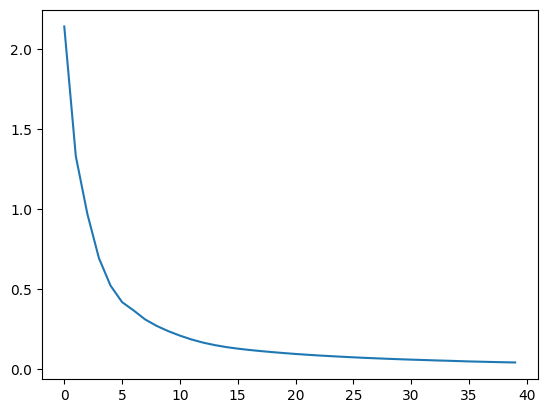

UnpicklingError: Weights only load failed. This file can still be loaded, to do so you have two options, [1mdo those steps only if you trust the source of the checkpoint[0m. 
	(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
	(2) Alternatively, to load with `weights_only=True` please check the recommended steps in the following error message.
	WeightsUnpickler error: Unsupported global: GLOBAL __main__.RNNODE was not an allowed global by default. Please use `torch.serialization.add_safe_globals([RNNODE])` or the `torch.serialization.safe_globals([RNNODE])` context manager to allowlist this global if you trust this class/function.

Check the documentation of torch.load to learn more about types accepted by default with weights_only https

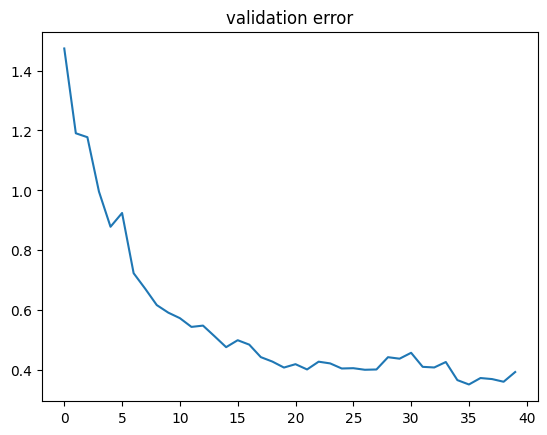

In [32]:
# RNN_ODE, number of grids >= 16


num_grids_non_adap_list1 = np.arange(16,68,4, dtype=int)+1#np.arange(24,102,6, dtype=int)+1#

odefunc_non_adap_list1, outputfunc_non_adap_list1 = [], []
fit_window_train_non_adap_list1, fit_window_test_non_adap_list1 = [], []
fit_L2_err_train_non_adap_list1, fit_L2_err_test_non_adap_list1 = [], []
fit_L1_err_train_non_adap_list1, fit_L1_err_test_non_adap_list1 = [], []

fit_L2_err_train_non_adap_mean_list1, fit_L2_err_test_non_adap_mean_list1 = [], []
fit_L2_err_train_non_adap_std_list1, fit_L2_err_test_non_adap_std_list1 = [], []


pred_window_train_non_adap_list1, pred_window_test_non_adap_list1 = [], []
pred_window_train_non_adap_list1_pre, pred_window_test_non_adap_list1_pre = [], []
pred_L2_err_train_non_adap_list1, pred_L2_err_test_non_adap_list1 = [], []
pred_L1_err_train_non_adap_list1, pred_L1_err_test_non_adap_list1 = [], []

pred_L2_err_train_non_adap_mean_list1, pred_L2_err_test_non_adap_mean_list1 = [], []
pred_L2_err_train_non_adap_std_list1, pred_L2_err_test_non_adap_std_list1 = [], []


batch_size = 64#128
verbose = 2
method = "naiveEuler"#"rk4"
buffer_start_steps = 2
n_iter = 40
rescale_const = 1

t1 = time.time()
index = np.arange(num_fine_grid+1)
for i, num_grids in enumerate(num_grids_non_adap_list1):
    print('\n----------------------------------------------------------------\n')
    print('\nnon-adaptive method, number of grids = %d\n' % num_grids)
    index1 = np.round(np.arange(num_grids-1) * num_fine_grid/(num_grids-1))
    index1 = np.concatenate(([index1[0]]*buffer_start_steps, index1, [num_fine_grid]))

    print('train models:\n')

    odefunc1_list, outputfunc1_list = [], []
    fit_window_train1_list, fit_window_test1_list = [], []
    fit_L2_err_train1_list, fit_L2_err_test1_list = [], []
    fit_L1_err_train1_list, fit_L1_err_test1_list = [], []

    pred_window_train1_list, pred_window_test1_list = [], []
    pred_window_train1_list_pre, pred_window_test1_list_pre = [], []
    pred_L2_err_train1_list, pred_L2_err_test1_list = [], []
    pred_L1_err_train1_list, pred_L1_err_test1_list = [], []

    rep = 0
    while rep <= num_rep-1:

        train_windows0 = train_windows0_list[rep]
        train_ts0 = train_ts0_list[rep]
        test_windows0 = test_windows0_list[rep]
        test_ts0 = test_ts0_list[rep]

        train_ts1 = torch.tensor(np.linspace(train_ts0[:,0], train_ts0[:,-1], num_grids).T)
        train_ts1 = torch.concat((train_ts1[:,0].reshape(train_ts0.shape[0],1).repeat(1,buffer_start_steps),
                                train_ts1),axis=1)
        train_windows1 = interpolate_window(train_windows0, train_ts0, train_ts1, 'cubic')

        if buffer_start_steps > 0:
            deltat = train_ts1[0][-1] - train_ts1[0][-2]
            train_ts1[:,:buffer_start_steps] = (train_ts1[:,:buffer_start_steps] +
                                                torch.arange(-deltat*buffer_start_steps, 0, deltat))
        valid_index = np.sort(npr.choice(train_windows0.shape[0], 50, replace=False))
        valid_windows0 = train_windows0[valid_index,:,:]
        valid_ts0 = train_ts0[valid_index,:]

        train_index = np.delete(np.arange(train_windows0.shape[0]), valid_index)

        train_loader1 = torch.utils.data.DataLoader(
            MyDataset(train_windows=train_windows1[train_index,:,:], train_ts=train_ts1[train_index,:]),
            shuffle=True, batch_size=batch_size,) # rescale the data

        input_steps1 = train_windows1.shape[1]

        print('\n------the %d-th replica:--------' % (rep+1))
        flag, odefunc1, outputfunc1 = train_non_adap_models(train_loader1, input_steps1, valid_windows0, valid_ts0, num_grids,
                                                            verbose, n_iter=n_iter, method=method, thres1=6.5e2, thres2=6.5e2, weight=(1,0),
                                                            obs_dim=obs_dim, n_hidden=n_hidden, n_latent=n_latent, num_train_windows=500,
                                                            time_scale=time_scale, buffer_start_steps=buffer_start_steps)

        if not flag:
            continue
        else:
            rep += 1

        print('\nfitting error of training data:')
        fit_window_train1, fit_L2_err_train1, fit_L1_err_train1 = fit_non_adap_models_grids(
            odefunc1, outputfunc1, train_windows0, train_ts0, num_grids, method=method, buffer_start_steps=buffer_start_steps,
            n_latent=n_latent, obs_dim=obs_dim, rescale_const=rescale_const, time_scale=time_scale)
        print('\nfitting error of testing data:')
        fit_window_test1, fit_L2_err_test1, fit_L1_err_test1 = fit_non_adap_models_grids(
            odefunc1, outputfunc1, test_windows0, test_ts0, num_grids, method=method, buffer_start_steps=buffer_start_steps,
            n_latent=n_latent, obs_dim=obs_dim, rescale_const=rescale_const, time_scale=time_scale)

        print('\npredicting error of training data:')
        pred_window_train1_pre, pred_window_train1, pred_L2_err_train1, pred_L1_err_train1 = pred_non_adap_models_grids(
            odefunc1, outputfunc1, train_windows0, train_ts0, num_grids, buffer_start_steps=buffer_start_steps,
            n_latent=n_latent, obs_dim=obs_dim, rescale_const=rescale_const, time_scale=time_scale)
        print('\npredicting error of testing data:')
        pred_window_test1_pre, pred_window_test1, pred_L2_err_test1, pred_L1_err_test1 = pred_non_adap_models_grids(
            odefunc1, outputfunc1, test_windows0, test_ts0, num_grids, buffer_start_steps=buffer_start_steps,
            n_latent=n_latent, obs_dim=obs_dim, rescale_const=rescale_const, time_scale=time_scale)

        odefunc1_list.append(copy.deepcopy(odefunc1))
        outputfunc1_list.append(copy.deepcopy(outputfunc1))
        fit_L2_err_train1_list.append(fit_L2_err_train1)
        fit_L2_err_test1_list.append(fit_L2_err_test1)
        fit_L1_err_train1_list.append(fit_L1_err_train1)
        fit_L1_err_test1_list.append(fit_L1_err_test1)
        fit_window_train1_list.append(fit_window_train1)
        fit_window_test1_list.append(fit_window_test1)

        pred_L2_err_train1_list.append(pred_L2_err_train1)
        pred_L2_err_test1_list.append(pred_L2_err_test1)
        pred_L1_err_train1_list.append(pred_L1_err_train1)
        pred_L1_err_test1_list.append(pred_L1_err_test1)
        pred_window_train1_list.append(pred_window_train1)
        pred_window_test1_list.append(pred_window_test1)
        pred_window_train1_list_pre.append(pred_window_train1_pre)
        pred_window_test1_list_pre.append(pred_window_test1_pre)

    odefunc_non_adap_list1.append(odefunc1_list)
    outputfunc_non_adap_list1.append(outputfunc1_list)
    fit_window_train_non_adap_list1.append(fit_window_train1_list)
    fit_window_test_non_adap_list1.append(fit_window_test1_list)
    fit_L2_err_train_non_adap_list1.append(fit_L2_err_train1_list)
    fit_L2_err_test_non_adap_list1.append(fit_L2_err_test1_list)
    fit_L1_err_train_non_adap_list1.append(fit_L1_err_train1_list)
    fit_L1_err_test_non_adap_list1.append(fit_L1_err_test1_list)

    fit_L2_err_train_ave = np.mean(torch.stack(fit_L2_err_train1_list).numpy(),axis=(1,))
    fit_L2_err_test_ave = np.mean(torch.stack(fit_L2_err_test1_list).numpy(),axis=(1,))
    fit_L2_err_train_non_adap_mean_list1.append(np.mean(fit_L2_err_train_ave))
    fit_L2_err_train_non_adap_std_list1.append(np.std(fit_L2_err_train_ave))
    fit_L2_err_test_non_adap_mean_list1.append(np.mean(fit_L2_err_test_ave))
    fit_L2_err_test_non_adap_std_list1.append(np.std(fit_L2_err_test_ave))

    print('\nL2 fitting error of training data: mean = %.2e, std = %.2e' % (np.mean(fit_L2_err_train_ave),
                                                                         np.std(fit_L2_err_train_ave)))
    print('\nL2 fitting error of testing data: mean = %.2e, std = %.2e' % (np.mean(fit_L2_err_test_ave),
                                                                         np.std(fit_L2_err_test_ave)))

    pred_window_train_non_adap_list1.append(pred_window_train1_list)
    pred_window_test_non_adap_list1.append(pred_window_test1_list)
    pred_window_train_non_adap_list1_pre.append(pred_window_train1_list_pre)
    pred_window_test_non_adap_list1_pre.append(pred_window_test1_list_pre)
    pred_L2_err_train_non_adap_list1.append(pred_L2_err_train1_list)
    pred_L2_err_test_non_adap_list1.append(pred_L2_err_test1_list)
    pred_L1_err_train_non_adap_list1.append(pred_L1_err_train1_list)
    pred_L1_err_test_non_adap_list1.append(pred_L1_err_test1_list)

    pred_L2_err_train_ave = np.mean(torch.stack(pred_L2_err_train1_list).numpy(),axis=(1,))
    pred_L2_err_test_ave = np.mean(torch.stack(pred_L2_err_test1_list).numpy(),axis=(1,))
    pred_L2_err_train_non_adap_mean_list1.append(np.mean(pred_L2_err_train_ave))
    pred_L2_err_train_non_adap_std_list1.append(np.std(pred_L2_err_train_ave))
    pred_L2_err_test_non_adap_mean_list1.append(np.mean(pred_L2_err_test_ave))
    pred_L2_err_test_non_adap_std_list1.append(np.std(pred_L2_err_test_ave))

    print('\nL2 predicting error of training data: mean = %.2e, std = %.2e' % (np.mean(pred_L2_err_train_ave),
                                                                         np.std(pred_L2_err_train_ave)))
    print('\nL2 predicting error of testing data: mean = %.2e, std = %.2e' % (np.mean(pred_L2_err_test_ave),
                                                                         np.std(pred_L2_err_test_ave)))

t2 = time.time()
print('training model takes %.2f s' % (t2-t1) )



----------------------------------------------------------------


non-adaptive method, number of grids = 7

train models:



<ipython-input-33-bf1cc778a423>:58: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  train_ts1 = torch.tensor(np.linspace(train_ts0[:,0], train_ts0[:,-1], num_grids).T)



------the 1-th replica:--------


<ipython-input-19-464b88938c95>:78: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  test_ts2 = torch.tensor(np.linspace(ts_orig[:, 0], ts_orig[:, -1], num_grids).T)
<ipython-input-19-464b88938c95>:135: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  pred_window_test2_temp[i, :, k] = torch.tensor(f(x2))  # [1:]
<ipython-input-19-464b88938c95>:141: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  pred_L2_err_test2 = torch.mean(torch.sum((window_orig[:, -(ts_orig.shape[1] - 1) // 2:, :] - pred_window_test2) ** 2
<ipython-input-19-464b88938c95>:143: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (po

the 1-th epoch, training loss = 2.5102e+00, remaining time = 0:00:20.215776
the 2-th epoch, training loss = 1.5078e+00, remaining time = 0:00:18.557455
the 3-th epoch, training loss = 1.0179e+00, remaining time = 0:00:15.239105
the 4-th epoch, training loss = 7.5995e-01, remaining time = 0:00:13.823371
the 5-th epoch, training loss = 6.2197e-01, remaining time = 0:00:12.771148
the 6-th epoch, training loss = 4.9894e-01, remaining time = 0:00:11.953107
the 7-th epoch, training loss = 4.1478e-01, remaining time = 0:00:11.152661
the 8-th epoch, training loss = 3.4831e-01, remaining time = 0:00:10.669032
the 9-th epoch, training loss = 2.9447e-01, remaining time = 0:00:10.136057
the 10-th epoch, training loss = 2.6079e-01, remaining time = 0:00:09.666104
the 11-th epoch, training loss = 2.3243e-01, remaining time = 0:00:09.195807
the 12-th epoch, training loss = 2.1222e-01, remaining time = 0:00:08.837985
the 13-th epoch, training loss = 1.9856e-01, remaining time = 0:00:08.494065
the 14-t

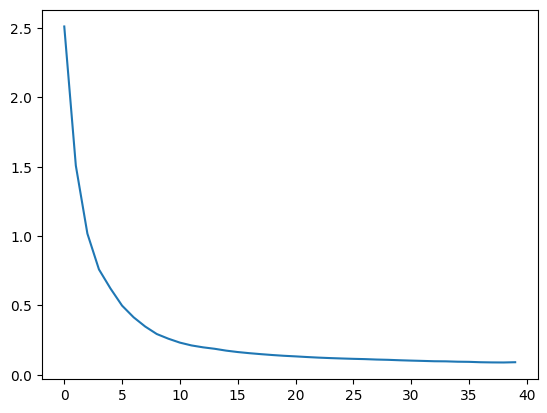

UnpicklingError: Weights only load failed. This file can still be loaded, to do so you have two options, [1mdo those steps only if you trust the source of the checkpoint[0m. 
	(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
	(2) Alternatively, to load with `weights_only=True` please check the recommended steps in the following error message.
	WeightsUnpickler error: Unsupported global: GLOBAL __main__.RNNODE was not an allowed global by default. Please use `torch.serialization.add_safe_globals([RNNODE])` or the `torch.serialization.safe_globals([RNNODE])` context manager to allowlist this global if you trust this class/function.

Check the documentation of torch.load to learn more about types accepted by default with weights_only https

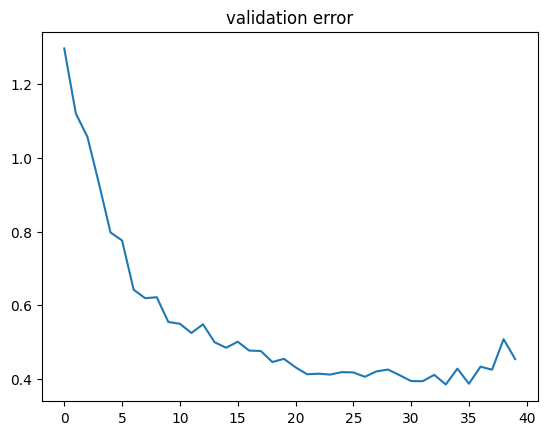

In [33]:
# non-adaptive method, interpolate to get the regular time steps (validation data), smaller number of grids


num_grids_non_adap_list2 = np.array([6,8,12])+1#np.arange(24,102,6, dtype=int)+1#

odefunc_non_adap_list2, outputfunc_non_adap_list2 = [], []
fit_window_train_non_adap_list2, fit_window_test_non_adap_list2 = [], []
fit_L2_err_train_non_adap_list2, fit_L2_err_test_non_adap_list2 = [], []
fit_L1_err_train_non_adap_list2, fit_L1_err_test_non_adap_list2 = [], []

fit_L2_err_train_non_adap_mean_list2, fit_L2_err_test_non_adap_mean_list2 = [], []
fit_L2_err_train_non_adap_std_list2, fit_L2_err_test_non_adap_std_list2 = [], []


pred_window_train_non_adap_list2, pred_window_test_non_adap_list2 = [], []
pred_window_train_non_adap_list2_pre, pred_window_test_non_adap_list2_pre = [], []
pred_L2_err_train_non_adap_list2, pred_L2_err_test_non_adap_list2 = [], []
pred_L1_err_train_non_adap_list2, pred_L1_err_test_non_adap_list2 = [], []

pred_L2_err_train_non_adap_mean_list2, pred_L2_err_test_non_adap_mean_list2 = [], []
pred_L2_err_train_non_adap_std_list2, pred_L2_err_test_non_adap_std_list2 = [], []



batch_size = 64#128
verbose = 2
method = "naiveEuler"#"rk4"
buffer_start_steps = 2

t1 = time.time()
index = np.arange(num_fine_grid+1)
for i, num_grids in enumerate(num_grids_non_adap_list2):
    print('\n----------------------------------------------------------------\n')
    print('\nnon-adaptive method, number of grids = %d\n' % num_grids)
    index1 = np.round(np.arange(num_grids-1) * num_fine_grid/(num_grids-1))
    index1 = np.concatenate(([index1[0]]*buffer_start_steps, index1, [num_fine_grid]))

    print('train models:\n')

    odefunc1_list, outputfunc1_list = [], []
    fit_window_train1_list, fit_window_test1_list = [], []
    fit_L2_err_train1_list, fit_L2_err_test1_list = [], []
    fit_L1_err_train1_list, fit_L1_err_test1_list = [], []

    pred_window_train1_list, pred_window_test1_list = [], []
    pred_window_train1_list_pre, pred_window_test1_list_pre = [], []
    pred_L2_err_train1_list, pred_L2_err_test1_list = [], []
    pred_L1_err_train1_list, pred_L1_err_test1_list = [], []

    rep = 0
    while rep <= num_rep-1:

        train_windows0 = train_windows0_list[rep]
        train_ts0 = train_ts0_list[rep]
        test_windows0 = test_windows0_list[rep]
        test_ts0 = test_ts0_list[rep]

        train_ts1 = torch.tensor(np.linspace(train_ts0[:,0], train_ts0[:,-1], num_grids).T)
        train_ts1 = torch.concat((train_ts1[:,0].reshape(train_ts0.shape[0],1).repeat(1,buffer_start_steps),
                                train_ts1),axis=1)
        train_windows1 = interpolate_window(train_windows0, train_ts0, train_ts1, 'cubic')

        if buffer_start_steps > 0:
            deltat = train_ts1[0][-1] - train_ts1[0][-2]
            train_ts1[:,:buffer_start_steps] = (train_ts1[:,:buffer_start_steps] +
                                                torch.arange(-deltat*buffer_start_steps, 0, deltat))
        valid_index = np.sort(npr.choice(train_windows0.shape[0], 50, replace=False))
        valid_windows0 = train_windows0[valid_index,:,:]
        valid_ts0 = train_ts0[valid_index,:]

        train_index = np.delete(np.arange(train_windows0.shape[0]), valid_index)

        train_loader1 = torch.utils.data.DataLoader(
            MyDataset(train_windows=train_windows1[train_index,:,:], train_ts=train_ts1[train_index,:]),
            shuffle=True, batch_size=batch_size,) # rescale the data

        input_steps1 = train_windows1.shape[1]

        print('\n------the %d-th replica:--------' % (rep+1))
        flag, odefunc1, outputfunc1 = train_non_adap_models(train_loader1, input_steps1, valid_windows0, valid_ts0, num_grids,
                                                            verbose, n_iter=n_iter, method=method, thres1=6.5e2, thres2=6.5e2, weight=(1,0),
                                                            obs_dim=obs_dim, n_hidden=n_hidden, n_latent=n_latent, num_train_windows=500,
                                                            time_scale=time_scale, buffer_start_steps=buffer_start_steps)
        if not flag:
            continue
        else:
            rep += 1

        print('\nfitting error of training data:')
        fit_window_train1, fit_L2_err_train1, fit_L1_err_train1 = fit_non_adap_models_grids(
            odefunc1, outputfunc1, train_windows0, train_ts0, num_grids, method=method, buffer_start_steps=buffer_start_steps,
            n_latent=n_latent, obs_dim=obs_dim, rescale_const=rescale_const, time_scale=time_scale)
        print('\nfitting error of testing data:')
        fit_window_test1, fit_L2_err_test1, fit_L1_err_test1 = fit_non_adap_models_grids(
            odefunc1, outputfunc1, test_windows0, test_ts0, num_grids, method=method, buffer_start_steps=buffer_start_steps,
            n_latent=n_latent, obs_dim=obs_dim, rescale_const=rescale_const, time_scale=time_scale)

        print('\npredicting error of training data:')
        pred_window_train1_pre, pred_window_train1, pred_L2_err_train1, pred_L1_err_train1 = pred_non_adap_models_grids(
            odefunc1, outputfunc1, train_windows0, train_ts0, num_grids, buffer_start_steps=buffer_start_steps,
            n_latent=n_latent, obs_dim=obs_dim, rescale_const=rescale_const, time_scale=time_scale)
        print('\npredicting error of testing data:')
        pred_window_test1_pre, pred_window_test1, pred_L2_err_test1, pred_L1_err_test1 = pred_non_adap_models_grids(
            odefunc1, outputfunc1, test_windows0, test_ts0, num_grids, buffer_start_steps=buffer_start_steps,
            n_latent=n_latent, obs_dim=obs_dim, rescale_const=rescale_const, time_scale=time_scale)

        odefunc1_list.append(copy.deepcopy(odefunc1))
        outputfunc1_list.append(copy.deepcopy(outputfunc1))
        fit_L2_err_train1_list.append(fit_L2_err_train1)
        fit_L2_err_test1_list.append(fit_L2_err_test1)
        fit_L1_err_train1_list.append(fit_L1_err_train1)
        fit_L1_err_test1_list.append(fit_L1_err_test1)
        fit_window_train1_list.append(fit_window_train1)
        fit_window_test1_list.append(fit_window_test1)

        pred_L2_err_train1_list.append(pred_L2_err_train1)
        pred_L2_err_test1_list.append(pred_L2_err_test1)
        pred_L1_err_train1_list.append(pred_L1_err_train1)
        pred_L1_err_test1_list.append(pred_L1_err_test1)
        pred_window_train1_list.append(pred_window_train1)
        pred_window_test1_list.append(pred_window_test1)
        pred_window_train1_list_pre.append(pred_window_train1_pre)
        pred_window_test1_list_pre.append(pred_window_test1_pre)

    odefunc_non_adap_list2.append(odefunc1_list)
    outputfunc_non_adap_list2.append(outputfunc1_list)
    fit_window_train_non_adap_list2.append(fit_window_train1_list)
    fit_window_test_non_adap_list2.append(fit_window_test1_list)
    fit_L2_err_train_non_adap_list2.append(fit_L2_err_train1_list)
    fit_L2_err_test_non_adap_list2.append(fit_L2_err_test1_list)
    fit_L1_err_train_non_adap_list2.append(fit_L1_err_train1_list)
    fit_L1_err_test_non_adap_list2.append(fit_L1_err_test1_list)

    fit_L2_err_train_ave = np.mean(torch.stack(fit_L2_err_train1_list).numpy(),axis=(1,))
    fit_L2_err_test_ave = np.mean(torch.stack(fit_L2_err_test1_list).numpy(),axis=(1,))
    fit_L2_err_train_non_adap_mean_list2.append(np.mean(fit_L2_err_train_ave))
    fit_L2_err_train_non_adap_std_list2.append(np.std(fit_L2_err_train_ave))
    fit_L2_err_test_non_adap_mean_list2.append(np.mean(fit_L2_err_test_ave))
    fit_L2_err_test_non_adap_std_list2.append(np.std(fit_L2_err_test_ave))

    print('\nL2 fitting error of training data: mean = %.2e, std = %.2e' % (np.mean(fit_L2_err_train_ave),
                                                                         np.std(fit_L2_err_train_ave)))
    print('\nL2 fitting error of testing data: mean = %.2e, std = %.2e' % (np.mean(fit_L2_err_test_ave),
                                                                         np.std(fit_L2_err_test_ave)))

    pred_window_train_non_adap_list2.append(pred_window_train1_list)
    pred_window_test_non_adap_list2.append(pred_window_test1_list)
    pred_window_train_non_adap_list2_pre.append(pred_window_train1_list_pre)
    pred_window_test_non_adap_list2_pre.append(pred_window_test1_list_pre)
    pred_L2_err_train_non_adap_list2.append(pred_L2_err_train1_list)
    pred_L2_err_test_non_adap_list2.append(pred_L2_err_test1_list)
    pred_L1_err_train_non_adap_list2.append(pred_L1_err_train1_list)
    pred_L1_err_test_non_adap_list2.append(pred_L1_err_test1_list)

    pred_L2_err_train_ave = np.mean(torch.stack(pred_L2_err_train1_list).numpy(),axis=(1,))
    pred_L2_err_test_ave = np.mean(torch.stack(pred_L2_err_test1_list).numpy(),axis=(1,))
    pred_L2_err_train_non_adap_mean_list2.append(np.mean(pred_L2_err_train_ave))
    pred_L2_err_train_non_adap_std_list2.append(np.std(pred_L2_err_train_ave))
    pred_L2_err_test_non_adap_mean_list2.append(np.mean(pred_L2_err_test_ave))
    pred_L2_err_test_non_adap_std_list2.append(np.std(pred_L2_err_test_ave))

    print('\nL2 predicting error of training data: mean = %.2e, std = %.2e' % (np.mean(pred_L2_err_train_ave),
                                                                         np.std(pred_L2_err_train_ave)))
    print('\nL2 predicting error of testing data: mean = %.2e, std = %.2e' % (np.mean(pred_L2_err_test_ave),
                                                                         np.std(pred_L2_err_test_ave)))

t2 = time.time()
print('training model takes %.2f s' % (t2-t1) )


In [34]:
# compute errors

pred_L2_err_test_non_adap_list_mean_mat1 = np.zeros((num_rep, len(num_grids_non_adap_list1)))

for i in range(len(num_grids_non_adap_list1)):
    pred_L2_err_test_non_adap_list_mean_mat1[:,i] = torch.stack(pred_L2_err_test_non_adap_list1[i]).mean(axis=(1,)).numpy()


pred_L2_err_test_non_adap_list_mean_mat2 = np.zeros((num_rep, len(num_grids_non_adap_list2)))

for i in range(len(num_grids_non_adap_list2)):
    pred_L2_err_test_non_adap_list_mean_mat2[:,i] = torch.stack(pred_L2_err_test_non_adap_list2[i]).mean(axis=(1,)).numpy()



IndexError: list index out of range

# RNN_ODE_Adap models


----------------------------------------------------------------


------the 1-th replica:--------

adaptive method, thres = 3.00, number of grids = 17.0 (1.70e+01)

train models:



<ipython-input-20-fc283f2c0841>:122: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  pred_window_adap1_temp[i, :, k] = torch.tensor(f(x2))  # [1:]
<ipython-input-20-fc283f2c0841>:125: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  pred_L2_err_adap_train1 = torch.mean(torch.sum((window_orig[:, -pred_len:, :] - pred_window_adap1) ** 2
<ipython-input-20-fc283f2c0841>:127: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  pred_L1_err_adap_train1 = torch.mean(torch.sum((window_orig[:, -pred_len:, :] - pred_window_adap1) ** 2
<ipython-input-20-fc283f2c0841>:53: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtyp

the 1-th epoch, training loss = 2.0586e+00, remaining time = 0:00:18.993682
the 2-th epoch, training loss = 1.1935e+00, remaining time = 0:00:17.770821
the 3-th epoch, training loss = 8.5992e-01, remaining time = 0:00:17.821906
the 4-th epoch, training loss = 6.0570e-01, remaining time = 0:00:17.330801
the 5-th epoch, training loss = 4.5124e-01, remaining time = 0:00:16.739619
the 6-th epoch, training loss = 3.7808e-01, remaining time = 0:00:16.103676
the 7-th epoch, training loss = 3.3153e-01, remaining time = 0:00:15.617861
the 8-th epoch, training loss = 2.8847e-01, remaining time = 0:00:15.124156
the 9-th epoch, training loss = 2.5651e-01, remaining time = 0:00:14.848993
the 10-th epoch, training loss = 2.2578e-01, remaining time = 0:00:14.373595
the 11-th epoch, training loss = 2.0055e-01, remaining time = 0:00:13.851559
the 12-th epoch, training loss = 1.7971e-01, remaining time = 0:00:13.459281
the 13-th epoch, training loss = 1.6249e-01, remaining time = 0:00:13.062130
the 14-t

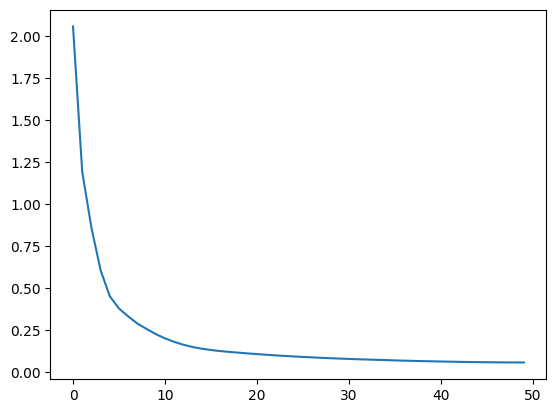

UnpicklingError: Weights only load failed. This file can still be loaded, to do so you have two options, [1mdo those steps only if you trust the source of the checkpoint[0m. 
	(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
	(2) Alternatively, to load with `weights_only=True` please check the recommended steps in the following error message.
	WeightsUnpickler error: Unsupported global: GLOBAL __main__.RNNODE was not an allowed global by default. Please use `torch.serialization.add_safe_globals([RNNODE])` or the `torch.serialization.safe_globals([RNNODE])` context manager to allowlist this global if you trust this class/function.

Check the documentation of torch.load to learn more about types accepted by default with weights_only https

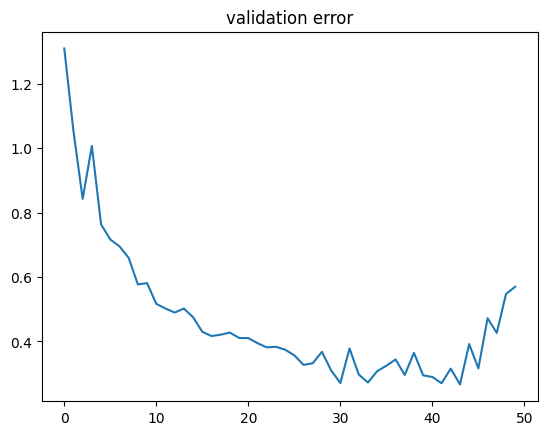

In [35]:
# RNN_ODE_Adap, number of grids >= 16

thres_list1 = ([0, 0.565, 0.615, 0.66, 0.73, 0.81, 0.91, 1.09] +
              [0.84, 0.91, 1.02, 1.18, 3])

rescale_const = 1
thres_list1.reverse()


verbose = 2
n_iter = 50

num_grids_adap_list1 = []

odefunc_adap_list1, outputfunc_adap_list1 = [], []

# fitting errors
fit_window_train_adap_list1_cubic, fit_window_test_adap_list1_cubic = [], []
fit_L2_err_train_adap_list1_cubic, fit_L2_err_test_adap_list1_cubic = [], []
fit_L1_err_train_adap_list1_cubic, fit_L1_err_test_adap_list1_cubic = [], []

fit_L2_err_train_adap_mean_list1_cubic, fit_L2_err_test_adap_mean_list1_cubic = [], []
fit_L2_err_train_adap_std_list1_cubic, fit_L2_err_test_adap_std_list1_cubic = [], []


# predicting errors
pred_window_test_adap_list1_cubic = []
pred_window_test_adap_list1_cubic_pre = []
pred_L2_err_test_adap_list1_cubic = []
pred_L1_err_test_adap_list1_cubic = []

pred_L2_err_test_adap_mean_list1_cubic = []
pred_L2_err_test_adap_std_list1_cubic = []


for i, thres in enumerate(thres_list1):

#     if i <= 1:
#         num_fine_adap = 64
#         num_layers_adap = 4
#     elif i <= 4:
#         num_fine_adap = 64
#         num_layers_adap = 3
#     else:
#         num_fine_adap = 64
#         num_layers_adap = 2
    if i <= 4:
        num_fine_adap = 64
        num_layers_adap = 3
    else:
        num_fine_adap = 64
        num_layers_adap = 2

    print('\n----------------------------------------------------------------\n')

    odefunc1_list1, outputfunc1_list1 = [], []

    fit_window_train1_list1_cubic, fit_window_test1_list1_cubic = [], []
    fit_L2_err_train1_list1_cubic, fit_L2_err_test1_list1_cubic = [], []
    fit_L1_err_train1_list1_cubic, fit_L1_err_test1_list1_cubic = [], []
    fit_window_train1_list1_linear, fit_window_test1_list1_linear = [], []
    fit_L2_err_train1_list1_linear, fit_L2_err_test1_list1_linear = [], []
    fit_L1_err_train1_list1_linear, fit_L1_err_test1_list1_linear = [], []

    pred_window_test1_list1_cubic = []
    pred_window_test1_list1_cubic_pre = []
    pred_L2_err_test1_list1_cubic = []
    pred_L1_err_test1_list1_cubic = []
    pred_window_test1_list1_linear = []
    pred_window_test1_list1_linear_pre = []
    pred_L2_err_test1_list1_linear = []
    pred_L1_err_test1_list1_linear = []

    num_grids_adap_list1_temp = []

    rep = 0
    while rep <= num_rep-1:

        print('\n------the %d-th replica:--------' % (rep+1))

        train_windows0 = train_windows0_list[rep]
        train_ts0 = train_ts0_list[rep]
        test_windows0 = test_windows0_list[rep]
        test_ts0 = test_ts0_list[rep]

        train_windows0_adap_buffer, train_ts0_adap_buffer, train_len0_adap_buffer, train_windows_adap_len = create_adap_data_buffer(
            train_windows0, train_ts0, thres, num_fine_adap, num_layers_adap)
        test_windows0_adap_buffer, test_ts0_adap_buffer, test_len0_adap_buffer, _ = create_adap_data_buffer(
            test_windows0, test_ts0, thres, num_fine_adap, num_layers_adap)
        # train_windows, 1st half
        train_windows0_adap_buffer_trunc, train_ts0_adap_buffer_trunc, _, _, train_time_index = create_adap_data_buffer(
            train_windows0[:,:(train_ts0.shape[1]+1)//2,:], train_ts0[:,:(train_ts0.shape[1]+1)//2], thres, num_fine_adap//2, num_layers_adap, return_index=1)
        # train_windows, 2nd half
        _, train_ts0_adap_buffer_trunc2, train_len0_adap_buffer_trunc2, _ = create_adap_data_buffer(
            train_windows0[:,-(train_ts0.shape[1]+1)//2:,:], train_ts0[:,-(train_ts0.shape[1]+1)//2:], thres, num_fine_adap//2, num_layers_adap, buffer_start_steps=0)
        # test_windows, 1st half
        test_windows0_adap_buffer_trunc, test_ts0_adap_buffer_trunc, _, _, test_time_index = create_adap_data_buffer(
            test_windows0[:,:(test_ts0.shape[1]+1)//2,:], test_ts0[:,:(test_ts0.shape[1]+1)//2], thres, num_fine_adap//2, num_layers_adap, return_index=1)
        # test_windows, 2nd half
        _, test_ts0_adap_buffer_trunc2, test_len0_adap_buffer_trunc2, _ = create_adap_data_buffer(
            test_windows0[:,-(test_ts0.shape[1]+1)//2:,:], test_ts0[:,-(test_ts0.shape[1]+1)//2:], thres, num_fine_adap//2, num_layers_adap, buffer_start_steps=0)

        num_grids_adap_list1_temp.append(train_windows_adap_len)

#         print(train_windows0[:,:(train_ts0.shape[1]+1)//2,:].shape)

        print('\nadaptive method, thres = %.2f, number of grids = %.1f (%.2e)\n' % (thres, train_windows_adap_len, train_windows_adap_len))
        valid_index = np.sort(npr.choice(train_windows0.shape[0], 50, replace=False))
        valid_windows0 = train_windows0[valid_index,:,:]
        valid_ts0 = train_ts0[valid_index,:]
        valid_windows0_adap_buffer = train_windows0_adap_buffer[valid_index,:,:]
        valid_ts0_adap_buffer = train_ts0_adap_buffer[valid_index,:]
        valid_windows0_adap_buffer_trunc = train_windows0_adap_buffer_trunc[valid_index,:,:]
        valid_ts0_adap_buffer_trunc = train_ts0_adap_buffer_trunc[valid_index,:]

        train_index = np.delete(np.arange(train_windows0.shape[0]), valid_index)
        train_loader_adap1_buffer = torch.utils.data.DataLoader(
            MyDataset_adap(train_windows=train_windows0_adap_buffer[train_index], train_ts=train_ts0_adap_buffer[train_index],
                            train_data_len=np.array(train_len0_adap_buffer)[train_index]),
            shuffle=True, batch_size=batch_size,)
        input_steps_adap1_buffer = max(train_len0_adap_buffer)

        print('train models:\n')

        if i <= 1:
            valid_ts_adap_trunc2, valid_len_adap_trunc2 = valid_ts0[:, (valid_ts0.shape[1]-1)//2::1], [(valid_ts0.shape[1]-1)//2+1]*test_ts0.shape[0]
        elif i <= 4:
            valid_ts_adap_trunc2, valid_len_adap_trunc2 = valid_ts0[:, (valid_ts0.shape[1]-1)//2::1], [(valid_ts0.shape[1]-1)//2+1]*test_ts0.shape[0]
        else:
            valid_ts_adap_trunc2, valid_len_adap_trunc2 = valid_ts0[:, (valid_ts0.shape[1]-1)//2::1], [(valid_ts0.shape[1]-1)//2+1]*test_ts0.shape[0]

        flag, odefunc_adap1_buffer, outputfunc_adap1_buffer = train_adap_models(
            train_loader_adap1_buffer, input_steps_adap1_buffer, verbose,
            valid_window=valid_windows0, valid_ts=valid_ts0, valid_window_adap=valid_windows0_adap_buffer,
            valid_ts_adap=valid_ts0_adap_buffer, valid_window_adap_trunc=valid_windows0_adap_buffer_trunc,
            valid_ts_adap_trunc=valid_ts0_adap_buffer_trunc, buffer_start_steps=buffer_start_steps,
            weight=(1,0), n_iter=n_iter, thres1=1.5e3, valid_len=np.array(train_len0_adap_buffer)[valid_index],
            valid_ts_adap_trunc2=valid_ts_adap_trunc2, valid_len_adap_trunc2=valid_len_adap_trunc2,
            pred_len=(train_ts0.shape[1]-1)//2, rescale_const=rescale_const,
            n_latent=n_latent, obs_dim=obs_dim, time_scale=time_scale
        )

        if not flag:
            continue
        else:
            rep += 1

        odefunc1_list1.append(copy.deepcopy(odefunc_adap1_buffer))
        outputfunc1_list1.append(copy.deepcopy(outputfunc_adap1_buffer))

        if i <= 1:
            test_ts_adap_trunc2, test_len_adap_trunc2 = test_ts0[:, (test_ts0.shape[1]-1)//2::1], [(test_ts0.shape[1]-1)//2+1]*test_ts0.shape[0]
        elif i <= 4:
            test_ts_adap_trunc2, test_len_adap_trunc2 = test_ts0[:, (test_ts0.shape[1]-1)//2::1], [(test_ts0.shape[1]-1)//2+1]*test_ts0.shape[0]
        else:
            test_ts_adap_trunc2, test_len_adap_trunc2 = test_ts0[:, (test_ts0.shape[1]-1)//2::1], [(test_ts0.shape[1]-1)//2+1]*test_ts0.shape[0]
        print(test_ts_adap_trunc2.shape)
        interp_kind = 'cubic'
        print('\nfitting error of training data (cubic):')
        fit_window_adap_train1, fit_L2_err_adap_train1, fit_L1_err_adap_train1 = fit_adap_models(
            odefunc_adap1_buffer, outputfunc_adap1_buffer, train_windows0, train_ts0,
            train_windows0_adap_buffer, train_ts0_adap_buffer, train_len0_adap_buffer, buffer_start_steps,
            interp_kind=interp_kind, rescale_const=rescale_const, n_latent=n_latent, obs_dim=obs_dim, time_scale=time_scale
        )
        print('fitting error of testing data (cubic):')
        fit_window_adap_test1, fit_L2_err_adap_test1, fit_L1_err_adap_test1 = fit_adap_models(
            odefunc_adap1_buffer, outputfunc_adap1_buffer, test_windows0, test_ts0,
            test_windows0_adap_buffer, test_ts0_adap_buffer, test_len0_adap_buffer, buffer_start_steps,
            interp_kind=interp_kind, rescale_const=rescale_const, n_latent=n_latent, obs_dim=obs_dim, time_scale=time_scale
        )
        fit_L2_err_train1_list1_cubic.append(fit_L2_err_adap_train1)
        fit_L2_err_test1_list1_cubic.append(fit_L2_err_adap_test1)
        fit_L1_err_train1_list1_cubic.append(fit_L1_err_adap_train1)
        fit_L1_err_test1_list1_cubic.append(fit_L1_err_adap_test1)
        fit_window_train1_list1_cubic.append(fit_window_adap_train1)
        fit_window_test1_list1_cubic.append(fit_window_adap_test1)

        print('predicting error of testing data (cubic):')
        pred_window_adap_test1_pre, pred_window_adap_test1, pred_L2_err_adap_test1, pred_L1_err_adap_test1 = pred_adap_models(
            odefunc_adap1_buffer, outputfunc_adap1_buffer, test_windows0, test_ts0,
            test_windows0_adap_buffer_trunc, test_ts0_adap_buffer_trunc, rescale_const=rescale_const,
            ts_adap_buffer_trunc2=test_ts_adap_trunc2, len_adap_buffer_trunc2=test_len_adap_trunc2,
            pred_len=(train_ts0.shape[1]-1)//2, buffer_start_steps=buffer_start_steps,interp_kind=interp_kind,
            n_latent=n_latent, obs_dim=obs_dim, time_scale=time_scale
        )

        pred_L2_err_test1_list1_cubic.append(pred_L2_err_adap_test1)
        pred_L1_err_test1_list1_cubic.append(pred_L1_err_adap_test1)
        pred_window_test1_list1_cubic.append(pred_window_adap_test1)
        pred_window_test1_list1_cubic_pre.append(pred_window_adap_test1_pre)



    odefunc_adap_list1.append(odefunc1_list1)
    outputfunc_adap_list1.append(outputfunc1_list1)
    num_grids_adap_list1.append(np.mean(num_grids_adap_list1_temp))

    fit_window_train_adap_list1_cubic.append(fit_window_train1_list1_cubic)
    fit_window_test_adap_list1_cubic.append(fit_window_test1_list1_cubic)
    fit_L2_err_train_adap_list1_cubic.append(fit_L2_err_train1_list1_cubic)
    fit_L2_err_test_adap_list1_cubic.append(fit_L2_err_test1_list1_cubic)
    fit_L1_err_train_adap_list1_cubic.append(fit_L1_err_train1_list1_cubic)
    fit_L1_err_test_adap_list1_cubic.append(fit_L1_err_test1_list1_cubic)

    fit_L2_err_train_ave_cubic = np.mean(torch.stack(fit_L2_err_train1_list1_cubic).numpy(),axis=(1,))
    fit_L2_err_test_ave_cubic = np.mean(torch.stack(fit_L2_err_test1_list1_cubic).numpy(),axis=(1,))

    fit_L2_err_train_adap_mean_list1_cubic.append(np.mean(fit_L2_err_train_ave_cubic))
    fit_L2_err_train_adap_std_list1_cubic.append(np.std(fit_L2_err_train_ave_cubic))
    fit_L2_err_test_adap_mean_list1_cubic.append(np.mean(fit_L2_err_test_ave_cubic))
    fit_L2_err_test_adap_std_list1_cubic.append(np.std(fit_L2_err_test_ave_cubic))

    print('\nL2 fitting error of training data (cubic): mean = %.2e, std = %.2e' % (np.mean(fit_L2_err_train_ave_cubic),
                                                                         np.std(fit_L2_err_train_ave_cubic)))
    pred_window_test_adap_list1_cubic.append(pred_window_test1_list1_cubic)
    pred_window_test_adap_list1_cubic_pre.append(pred_window_test1_list1_cubic_pre)
    pred_L2_err_test_adap_list1_cubic.append(pred_L2_err_test1_list1_cubic)
    pred_L1_err_test_adap_list1_cubic.append(pred_L1_err_test1_list1_cubic)

    pred_L2_err_test_ave_cubic = np.mean(torch.stack(pred_L2_err_test1_list1_cubic).numpy(),axis=(1,))

    pred_L2_err_test_adap_mean_list1_cubic.append(np.mean(pred_L2_err_test_ave_cubic))
    pred_L2_err_test_adap_std_list1_cubic.append(np.std(pred_L2_err_test_ave_cubic))

    print('\nL2 predicting error of testing data (cubic): mean = %.2e, std = %.2e' % (np.mean(pred_L2_err_test_ave_cubic),
                                                                         np.std(pred_L2_err_test_ave_cubic)))




----------------------------------------------------------------


------the 1-th replica:--------

adaptive method, thres = 0.90, number of grids = 5.9 (5.93e+00)

train models:



<ipython-input-20-fc283f2c0841>:122: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  pred_window_adap1_temp[i, :, k] = torch.tensor(f(x2))  # [1:]
<ipython-input-20-fc283f2c0841>:125: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  pred_L2_err_adap_train1 = torch.mean(torch.sum((window_orig[:, -pred_len:, :] - pred_window_adap1) ** 2
<ipython-input-20-fc283f2c0841>:127: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  pred_L1_err_adap_train1 = torch.mean(torch.sum((window_orig[:, -pred_len:, :] - pred_window_adap1) ** 2
<ipython-input-20-fc283f2c0841>:53: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtyp

the 1-th epoch, training loss = 2.0999e+00, remaining time = 0:00:11.822630
the 2-th epoch, training loss = 1.0951e+00, remaining time = 0:00:11.561022
the 3-th epoch, training loss = 7.2152e-01, remaining time = 0:00:11.024182
the 4-th epoch, training loss = 4.6429e-01, remaining time = 0:00:10.396275
the 5-th epoch, training loss = 3.5632e-01, remaining time = 0:00:09.970024
the 6-th epoch, training loss = 3.0875e-01, remaining time = 0:00:09.527806
the 7-th epoch, training loss = 2.6029e-01, remaining time = 0:00:09.383455
the 8-th epoch, training loss = 2.2807e-01, remaining time = 0:00:09.185615
the 9-th epoch, training loss = 2.0258e-01, remaining time = 0:00:09.193305
the 10-th epoch, training loss = 1.7730e-01, remaining time = 0:00:09.072078
the 11-th epoch, training loss = 1.5868e-01, remaining time = 0:00:08.904074
the 12-th epoch, training loss = 1.4367e-01, remaining time = 0:00:08.666666
the 13-th epoch, training loss = 1.3360e-01, remaining time = 0:00:08.454744
the 14-t

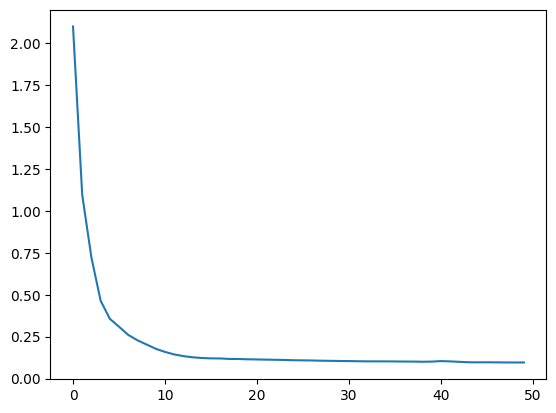

UnpicklingError: Weights only load failed. This file can still be loaded, to do so you have two options, [1mdo those steps only if you trust the source of the checkpoint[0m. 
	(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
	(2) Alternatively, to load with `weights_only=True` please check the recommended steps in the following error message.
	WeightsUnpickler error: Unsupported global: GLOBAL __main__.RNNODE was not an allowed global by default. Please use `torch.serialization.add_safe_globals([RNNODE])` or the `torch.serialization.safe_globals([RNNODE])` context manager to allowlist this global if you trust this class/function.

Check the documentation of torch.load to learn more about types accepted by default with weights_only https

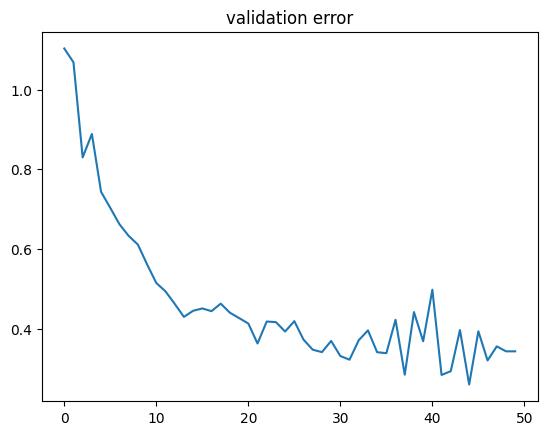

In [36]:
# RNN_ODE_Adap, number of grids < 16

thres_list2 = [
    0.9, # 8, 2
    0, # 8, 2
    0.7, # 16, 2
              ]

rescale_const = 1

verbose = 2

num_grids_adap_list2 = []

odefunc_adap_list2, outputfunc_adap_list2 = [], []

# fitting errors
fit_window_train_adap_list2_cubic, fit_window_test_adap_list2_cubic = [], []
fit_L2_err_train_adap_list2_cubic, fit_L2_err_test_adap_list2_cubic = [], []
fit_L1_err_train_adap_list2_cubic, fit_L1_err_test_adap_list2_cubic = [], []

fit_L2_err_train_adap_mean_list2_cubic, fit_L2_err_test_adap_mean_list2_cubic = [], []
fit_L2_err_train_adap_std_list2_cubic, fit_L2_err_test_adap_std_list2_cubic = [], []


# predicting errors
pred_window_test_adap_list2_cubic = []
pred_window_test_adap_list2_cubic_pre = []
pred_L2_err_test_adap_list2_cubic = []
pred_L1_err_test_adap_list2_cubic = []

pred_L2_err_test_adap_mean_list2_cubic = []
pred_L2_err_test_adap_std_list2_cubic = []


for i, thres in enumerate(thres_list2):

#     if i <= 1:
#         num_fine_adap = 64
#         num_layers_adap = 4
#     elif i <= 4:
#         num_fine_adap = 64
#         num_layers_adap = 3
#     else:
#         num_fine_adap = 64
#         num_layers_adap = 2

    if i <= 1:
        num_fine_adap = 8
        num_layers_adap = 2
    else:
        num_fine_adap = 16
        num_layers_adap = 2



    print('\n----------------------------------------------------------------\n')

    odefunc1_list2, outputfunc1_list2 = [], []

    fit_window_train1_list2_cubic, fit_window_test1_list2_cubic = [], []
    fit_L2_err_train1_list2_cubic, fit_L2_err_test1_list2_cubic = [], []
    fit_L1_err_train1_list2_cubic, fit_L1_err_test1_list2_cubic = [], []
    fit_window_train1_list2_linear, fit_window_test1_list2_linear = [], []
    fit_L2_err_train1_list2_linear, fit_L2_err_test1_list2_linear = [], []
    fit_L1_err_train1_list2_linear, fit_L1_err_test1_list2_linear = [], []

    pred_window_test1_list2_cubic = []
    pred_window_test1_list2_cubic_pre = []
    pred_L2_err_test1_list2_cubic = []
    pred_L1_err_test1_list2_cubic = []
    pred_window_test1_list2_linear = []
    pred_window_test1_list2_linear_pre = []
    pred_L2_err_test1_list2_linear = []
    pred_L1_err_test1_list2_linear = []

    num_grids_adap_list2_temp = []

    rep = 0
    while rep <= num_rep-1:

        print('\n------the %d-th replica:--------' % (rep+1))

        train_windows0 = train_windows0_list[rep]
        train_ts0 = train_ts0_list[rep]
        test_windows0 = test_windows0_list[rep]
        test_ts0 = test_ts0_list[rep]

        train_windows0_adap_buffer, train_ts0_adap_buffer, train_len0_adap_buffer, train_windows_adap_len = create_adap_data_buffer(
            train_windows0, train_ts0, thres, num_fine_adap, num_layers_adap)
        test_windows0_adap_buffer, test_ts0_adap_buffer, test_len0_adap_buffer, _ = create_adap_data_buffer(
            test_windows0, test_ts0, thres, num_fine_adap, num_layers_adap)
        # train_windows, 1st half
        train_windows0_adap_buffer_trunc, train_ts0_adap_buffer_trunc, _, _, train_time_index = create_adap_data_buffer(
            train_windows0[:,:(train_ts0.shape[1]+1)//2,:], train_ts0[:,:(train_ts0.shape[1]+1)//2], thres, num_fine_adap//2, num_layers_adap, return_index=1)
        # train_windows, 2nd half
        _, train_ts0_adap_buffer_trunc2, train_len0_adap_buffer_trunc2, _ = create_adap_data_buffer(
            train_windows0[:,-(train_ts0.shape[1]+1)//2:,:], train_ts0[:,-(train_ts0.shape[1]+1)//2:], thres, num_fine_adap//2, num_layers_adap, buffer_start_steps=0)
        # test_windows, 1st half
        test_windows0_adap_buffer_trunc, test_ts0_adap_buffer_trunc, _, _, test_time_index = create_adap_data_buffer(
            test_windows0[:,:(test_ts0.shape[1]+1)//2,:], test_ts0[:,:(test_ts0.shape[1]+1)//2], thres, num_fine_adap//2, num_layers_adap, return_index=1)
        # test_windows, 2nd half
        _, test_ts0_adap_buffer_trunc2, test_len0_adap_buffer_trunc2, _ = create_adap_data_buffer(
            test_windows0[:,-(test_ts0.shape[1]+1)//2:,:], test_ts0[:,-(test_ts0.shape[1]+1)//2:], thres, num_fine_adap//2, num_layers_adap, buffer_start_steps=0)

        num_grids_adap_list2_temp.append(train_windows_adap_len)

#         print(train_windows0[:,:(train_ts0.shape[1]+1)//2,:].shape)

        print('\nadaptive method, thres = %.2f, number of grids = %.1f (%.2e)\n' % (thres, train_windows_adap_len, train_windows_adap_len))
        valid_index = np.sort(npr.choice(train_windows0.shape[0], 50, replace=False))
        valid_windows0 = train_windows0[valid_index,:,:]
        valid_ts0 = train_ts0[valid_index,:]
        valid_windows0_adap_buffer = train_windows0_adap_buffer[valid_index,:,:]
        valid_ts0_adap_buffer = train_ts0_adap_buffer[valid_index,:]
        valid_windows0_adap_buffer_trunc = train_windows0_adap_buffer_trunc[valid_index,:,:]
        valid_ts0_adap_buffer_trunc = train_ts0_adap_buffer_trunc[valid_index,:]

        train_index = np.delete(np.arange(train_windows0.shape[0]), valid_index)
        train_loader_adap1_buffer = torch.utils.data.DataLoader(
            MyDataset_adap(train_windows=train_windows0_adap_buffer[train_index], train_ts=train_ts0_adap_buffer[train_index],
                            train_data_len=np.array(train_len0_adap_buffer)[train_index]),
            shuffle=True, batch_size=batch_size,)
        input_steps_adap1_buffer = max(train_len0_adap_buffer)

        print('train models:\n')

        if i <= 1:
            valid_ts_adap_trunc2, valid_len_adap_trunc2 = valid_ts0[:, (valid_ts0.shape[1]-1)//2::8], [(valid_ts0.shape[1]-1)//16+1]*test_ts0.shape[0]
        else:
            valid_ts_adap_trunc2, valid_len_adap_trunc2 = valid_ts0[:, (valid_ts0.shape[1]-1)//2::4], [(valid_ts0.shape[1]-1)//8+1]*test_ts0.shape[0]

        flag, odefunc_adap1_buffer, outputfunc_adap1_buffer = train_adap_models(
            train_loader_adap1_buffer, input_steps_adap1_buffer, verbose,
            valid_window=valid_windows0, valid_ts=valid_ts0, valid_window_adap=valid_windows0_adap_buffer,
            valid_ts_adap=valid_ts0_adap_buffer, valid_window_adap_trunc=valid_windows0_adap_buffer_trunc,
            valid_ts_adap_trunc=valid_ts0_adap_buffer_trunc, buffer_start_steps=buffer_start_steps,
            weight=[1,0], n_iter=n_iter, thres1=1.5e3, valid_len=np.array(train_len0_adap_buffer)[valid_index],
            valid_ts_adap_trunc2=valid_ts_adap_trunc2, valid_len_adap_trunc2=valid_len_adap_trunc2,
            pred_len=(train_ts0.shape[1]-1)//2, rescale_const=rescale_const,
            n_latent=n_latent, obs_dim=obs_dim, time_scale=time_scale
        )

        if not flag:
            continue
        else:
            rep += 1

        odefunc1_list2.append(copy.deepcopy(odefunc_adap1_buffer))
        outputfunc1_list2.append(copy.deepcopy(outputfunc_adap1_buffer))

        if i <= 1:
            test_ts_adap_trunc2, test_len_adap_trunc2 = test_ts0[:, (test_ts0.shape[1]-1)//2::8], [(test_ts0.shape[1]-1)//16+1]*test_ts0.shape[0]
        else:
            test_ts_adap_trunc2, test_len_adap_trunc2 = test_ts0[:, (test_ts0.shape[1]-1)//2::4], [(test_ts0.shape[1]-1)//8+1]*test_ts0.shape[0]
        print(test_ts_adap_trunc2.shape)
        interp_kind = 'cubic'
        print('\nfitting error of training data (cubic):')
        fit_window_adap_train1, fit_L2_err_adap_train1, fit_L1_err_adap_train1 = fit_adap_models(
            odefunc_adap1_buffer, outputfunc_adap1_buffer, train_windows0, train_ts0,
            train_windows0_adap_buffer, train_ts0_adap_buffer, train_len0_adap_buffer, buffer_start_steps,
            interp_kind=interp_kind, rescale_const=rescale_const, n_latent=n_latent, obs_dim=obs_dim, time_scale=time_scale
        )
        print('fitting error of testing data (cubic):')
        fit_window_adap_test1, fit_L2_err_adap_test1, fit_L1_err_adap_test1 = fit_adap_models(
            odefunc_adap1_buffer, outputfunc_adap1_buffer, test_windows0, test_ts0,
            test_windows0_adap_buffer, test_ts0_adap_buffer, test_len0_adap_buffer, buffer_start_steps,
            interp_kind=interp_kind, rescale_const=rescale_const, n_latent=n_latent, obs_dim=obs_dim, time_scale=time_scale
        )
        fit_L2_err_train1_list2_cubic.append(fit_L2_err_adap_train1)
        fit_L2_err_test1_list2_cubic.append(fit_L2_err_adap_test1)
        fit_L1_err_train1_list2_cubic.append(fit_L1_err_adap_train1)
        fit_L1_err_test1_list2_cubic.append(fit_L1_err_adap_test1)
        fit_window_train1_list2_cubic.append(fit_window_adap_train1)
        fit_window_test1_list2_cubic.append(fit_window_adap_test1)

        print('predicting error of testing data (cubic):')
        pred_window_adap_test1_pre, pred_window_adap_test1, pred_L2_err_adap_test1, pred_L1_err_adap_test1 = pred_adap_models(
            odefunc_adap1_buffer, outputfunc_adap1_buffer, test_windows0, test_ts0,
            test_windows0_adap_buffer_trunc, test_ts0_adap_buffer_trunc, rescale_const=rescale_const,
            ts_adap_buffer_trunc2=test_ts_adap_trunc2, len_adap_buffer_trunc2=test_len_adap_trunc2,
            pred_len=(train_ts0.shape[1]-1)//2, buffer_start_steps=buffer_start_steps,interp_kind=interp_kind,
            n_latent=n_latent, obs_dim=obs_dim, time_scale=time_scale
        )

        pred_L2_err_test1_list2_cubic.append(pred_L2_err_adap_test1)
        pred_L1_err_test1_list2_cubic.append(pred_L1_err_adap_test1)
        pred_window_test1_list2_cubic.append(pred_window_adap_test1)
        pred_window_test1_list2_cubic_pre.append(pred_window_adap_test1_pre)



    odefunc_adap_list2.append(odefunc1_list2)
    outputfunc_adap_list2.append(outputfunc1_list2)
    num_grids_adap_list2.append(np.mean(num_grids_adap_list2_temp))

    fit_window_train_adap_list2_cubic.append(fit_window_train1_list2_cubic)
    fit_window_test_adap_list2_cubic.append(fit_window_test1_list2_cubic)
    fit_L2_err_train_adap_list2_cubic.append(fit_L2_err_train1_list2_cubic)
    fit_L2_err_test_adap_list2_cubic.append(fit_L2_err_test1_list2_cubic)
    fit_L1_err_train_adap_list2_cubic.append(fit_L1_err_train1_list2_cubic)
    fit_L1_err_test_adap_list2_cubic.append(fit_L1_err_test1_list2_cubic)

    fit_L2_err_train_ave_cubic = np.mean(torch.stack(fit_L2_err_train1_list2_cubic).numpy(),axis=(1,))
    fit_L2_err_test_ave_cubic = np.mean(torch.stack(fit_L2_err_test1_list2_cubic).numpy(),axis=(1,))

    fit_L2_err_train_adap_mean_list2_cubic.append(np.mean(fit_L2_err_train_ave_cubic))
    fit_L2_err_train_adap_std_list2_cubic.append(np.std(fit_L2_err_train_ave_cubic))
    fit_L2_err_test_adap_mean_list2_cubic.append(np.mean(fit_L2_err_test_ave_cubic))
    fit_L2_err_test_adap_std_list2_cubic.append(np.std(fit_L2_err_test_ave_cubic))

    print('\nL2 fitting error of training data (cubic): mean = %.2e, std = %.2e' % (np.mean(fit_L2_err_train_ave_cubic),
                                                                         np.std(fit_L2_err_train_ave_cubic)))
    pred_window_test_adap_list2_cubic.append(pred_window_test1_list2_cubic)
    pred_window_test_adap_list2_cubic_pre.append(pred_window_test1_list2_cubic_pre)
    pred_L2_err_test_adap_list2_cubic.append(pred_L2_err_test1_list2_cubic)
    pred_L1_err_test_adap_list2_cubic.append(pred_L1_err_test1_list2_cubic)

    pred_L2_err_test_ave_cubic = np.mean(torch.stack(pred_L2_err_test1_list2_cubic).numpy(),axis=(1,))

    pred_L2_err_test_adap_mean_list2_cubic.append(np.mean(pred_L2_err_test_ave_cubic))
    pred_L2_err_test_adap_std_list2_cubic.append(np.std(pred_L2_err_test_ave_cubic))

    print('\nL2 predicting error of testing data (cubic): mean = %.2e, std = %.2e' % (np.mean(pred_L2_err_test_ave_cubic),
                                                                         np.std(pred_L2_err_test_ave_cubic)))


In [ ]:
# compute errors

pred_L2_err_test_adap_list_mean_mat1 = np.zeros((num_rep, len(num_grids_adap_list1)))

for i in range(len(num_grids_adap_list1)):
    pred_L2_err_test_adap_list_mean_mat1[:,i] = torch.stack(pred_L2_err_test_adap_list1_cubic[i]).mean(axis=(1,)).numpy()


pred_L2_err_test_adap_list_mean_mat2 = np.zeros((num_rep, len(num_grids_adap_list2)))

for i in range(len(num_grids_adap_list2)):
    pred_L2_err_test_adap_list_mean_mat2[:,i] = torch.stack(pred_L2_err_test_adap_list2_cubic[i]).mean(axis=(1,)).numpy()



# RNN models


----------------------------------------------------------------


non-adaptive method, number of grids = 17

train models:



<ipython-input-37-1081e3449804>:56: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  train_ts1 = torch.tensor(np.linspace(train_ts0[:,0], train_ts0[:,-1], num_grids).T)



------the 1-th replica:--------


<ipython-input-17-1f6007a69fcf>:67: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  test_ts2 = torch.tensor(np.linspace(ts_orig[:, 0], ts_orig[:, -1], num_grids).T)
<ipython-input-17-1f6007a69fcf>:115: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  pred_window_test2_temp[i, :, k] = torch.tensor(f(x2))  # [1:]
<ipython-input-17-1f6007a69fcf>:120: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  pred_L2_err_test2 = torch.mean(torch.sum((window_orig[:, -(ts_orig.shape[1] - 1) // 2:, :] - pred_window_test2) ** 2
<ipython-input-17-1f6007a69fcf>:122: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (po

the 1-th epoch, training loss = 1.4064e+00, remaining time = 0:00:11.836414
the 2-th epoch, training loss = 4.5046e-01, remaining time = 0:00:12.307986
the 3-th epoch, training loss = 1.6708e-01, remaining time = 0:00:11.828338
the 4-th epoch, training loss = 1.1060e-01, remaining time = 0:00:11.275756
the 5-th epoch, training loss = 6.1867e-02, remaining time = 0:00:10.861028
the 6-th epoch, training loss = 3.8377e-02, remaining time = 0:00:10.450195
the 7-th epoch, training loss = 2.6834e-02, remaining time = 0:00:10.049658
the 8-th epoch, training loss = 2.0804e-02, remaining time = 0:00:09.626026
the 9-th epoch, training loss = 1.7010e-02, remaining time = 0:00:09.267997
the 10-th epoch, training loss = 1.4086e-02, remaining time = 0:00:08.938206
the 11-th epoch, training loss = 1.2828e-02, remaining time = 0:00:08.748175
the 12-th epoch, training loss = 1.1788e-02, remaining time = 0:00:08.429195
the 13-th epoch, training loss = 1.1225e-02, remaining time = 0:00:08.129591
the 14-t

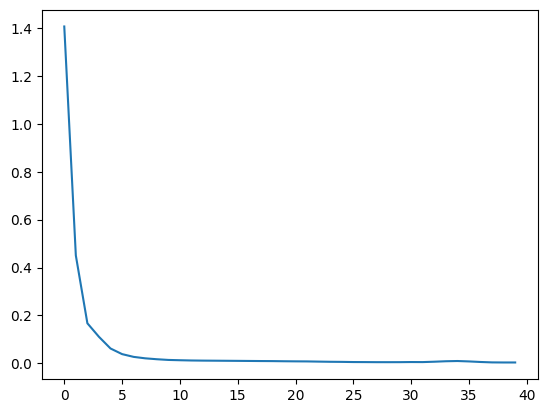

UnpicklingError: Weights only load failed. This file can still be loaded, to do so you have two options, [1mdo those steps only if you trust the source of the checkpoint[0m. 
	(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
	(2) Alternatively, to load with `weights_only=True` please check the recommended steps in the following error message.
	WeightsUnpickler error: Unsupported global: GLOBAL __main__.RNN was not an allowed global by default. Please use `torch.serialization.add_safe_globals([RNN])` or the `torch.serialization.safe_globals([RNN])` context manager to allowlist this global if you trust this class/function.

Check the documentation of torch.load to learn more about types accepted by default with weights_only https://pytorc

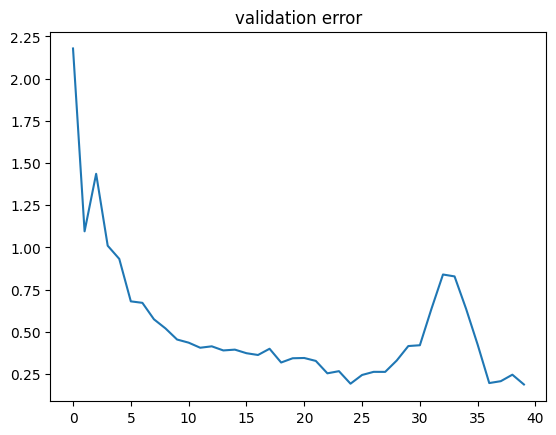

In [37]:
# RNN, number of grids >= 16

num_grids_RNN_list1 = np.arange(16,68,4, dtype=int)+1#np.arange(24,102,6, dtype=int)+1

rnnfunc_RNN_list1 = []
fit_window_train_RNN_list1, fit_window_test_RNN_list1 = [], []
fit_L2_err_train_RNN_list1, fit_L2_err_test_RNN_list1 = [], []
fit_L1_err_train_RNN_list1, fit_L1_err_test_RNN_list1 = [], []

fit_L2_err_train_RNN_mean_list1, fit_L2_err_test_RNN_mean_list1 = [], []
fit_L2_err_train_RNN_std_list1, fit_L2_err_test_RNN_std_list1 = [], []

pred_window_train_RNN_list1, pred_window_test_RNN_list1 = [], []
pred_window_train_RNN_list1_pre, pred_window_test_RNN_list1_pre = [], []
pred_L2_err_train_RNN_list1, pred_L2_err_test_RNN_list1 = [], []
pred_L1_err_train_RNN_list1, pred_L1_err_test_RNN_list1 = [], []

pred_L2_err_train_RNN_mean_list1, pred_L2_err_test_RNN_mean_list1 = [], []
pred_L2_err_train_RNN_std_list1, pred_L2_err_test_RNN_std_list1 = [], []

rng = np.random.default_rng()

batch_size = 64#128
verbose = 2
buffer_start_steps = 2
n_iter = 40

t1 = time.time()
index = np.arange(num_fine_grid+1)
for i, num_grids in enumerate(num_grids_RNN_list1):
    print('\n----------------------------------------------------------------\n')
    print('\nnon-adaptive method, number of grids = %d\n' % num_grids)
    index1 = np.round(np.arange(num_grids-1) * num_fine_grid/(num_grids-1))
    index1 = np.concatenate(([index1[0]]*buffer_start_steps, index1, [num_fine_grid]))

    print('train models:\n')

    rnn1_list = []
    fit_window_train1_list, fit_window_test1_list = [], []
    fit_L2_err_train1_list, fit_L2_err_test1_list = [], []
    fit_L1_err_train1_list, fit_L1_err_test1_list = [], []

    pred_window_train1_list, pred_window_test1_list = [], []
    pred_window_train1_list_pre, pred_window_test1_list_pre = [], []
    pred_L2_err_train1_list, pred_L2_err_test1_list = [], []
    pred_L1_err_train1_list, pred_L1_err_test1_list = [], []

    rep = 0
    while rep <= num_rep-1:

        train_windows0 = train_windows0_list[rep]
        train_ts0 = train_ts0_list[rep]
        test_windows0 = test_windows0_list[rep]
        test_ts0 = test_ts0_list[rep]

        train_ts1 = torch.tensor(np.linspace(train_ts0[:,0], train_ts0[:,-1], num_grids).T)
        train_ts1 = torch.concat((train_ts1[:,0].reshape(train_ts0.shape[0],1).repeat(1,buffer_start_steps),
                                train_ts1),axis=1)
        train_windows1 = interpolate_window(train_windows0, train_ts0, train_ts1, 'cubic')

        if buffer_start_steps > 0:
            deltat = train_ts1[0][-1] - train_ts1[0][-2]
            train_ts1[:,:buffer_start_steps] = (train_ts1[:,:buffer_start_steps] +
                                                torch.arange(-deltat*buffer_start_steps, 0, deltat))

        valid_index = np.sort(npr.choice(train_windows0.shape[0], 50, replace=False))
        valid_windows0 = train_windows0[valid_index,:,:]
        valid_ts0 = train_ts0[valid_index,:]

        train_index = np.delete(np.arange(train_windows0.shape[0]), valid_index)

        train_loader1 = torch.utils.data.DataLoader(
            MyDataset(train_windows=train_windows1[train_index,:,:], train_ts=train_ts1[train_index,:]),
            shuffle=True, batch_size=batch_size,) # rescale the data

        input_steps1 = train_windows1.shape[1]

        print('\n------the %d-th replica:--------' % (rep+1))
        flag, rnn1 = train_RNN(train_loader1, input_steps1, valid_windows0, valid_ts0, num_grids, verbose,
                                n_iter=n_iter, thres1=4e2, n_latent=n_latent, obs_dim=obs_dim, time_scale=time_scale )
        if not flag:
            continue
        else:
            rep += 1

        print('\nfitting error of training data:')
        fit_window_train1, fit_L2_err_train1, fit_L1_err_train1 = fit_RNN_grids(
            rnn1, train_windows0, train_ts0, num_grids, buffer_start_steps=buffer_start_steps,
            n_latent=n_latent, obs_dim=obs_dim)
        print('\nfitting error of testing data:')
        fit_window_test1, fit_L2_err_test1, fit_L1_err_test1 = fit_RNN_grids(
            rnn1, test_windows0, test_ts0, num_grids, buffer_start_steps=buffer_start_steps,
            n_latent=n_latent, obs_dim=obs_dim)


        rnn1_list.append((copy.deepcopy(rnn1)))

        fit_L2_err_train1_list.append(fit_L2_err_train1)
        fit_L2_err_test1_list.append(fit_L2_err_test1)
        fit_L1_err_train1_list.append(fit_L1_err_train1)
        fit_L1_err_test1_list.append(fit_L1_err_test1)
        fit_window_train1_list.append(fit_window_train1)
        fit_window_test1_list.append(fit_window_test1)

        print('\npredicting error of training data:')
        pred_window_train1_pre, pred_window_train1, pred_L2_err_train1, pred_L1_err_train1 = pred_RNN_grids(
            rnn1, train_windows0, train_ts0, num_grids, buffer_start_steps=buffer_start_steps,
            n_latent=n_latent, obs_dim=obs_dim)
        print('\npredicting error of testing data:')
        pred_window_test1_pre, pred_window_test1, pred_L2_err_test1, pred_L1_err_test1 = pred_RNN_grids(
            rnn1, test_windows0, test_ts0, num_grids, buffer_start_steps=buffer_start_steps,
            n_latent=n_latent, obs_dim=obs_dim)

        pred_L2_err_train1_list.append(pred_L2_err_train1)
        pred_L2_err_test1_list.append(pred_L2_err_test1)
        pred_L1_err_train1_list.append(pred_L1_err_train1)
        pred_L1_err_test1_list.append(pred_L1_err_test1)
        pred_window_train1_list.append(pred_window_train1)
        pred_window_test1_list.append(pred_window_test1)
        pred_window_train1_list_pre.append(pred_window_train1_pre)
        pred_window_test1_list_pre.append(pred_window_test1_pre)


    rnnfunc_RNN_list1.append(rnn1_list)

    fit_window_train_RNN_list1.append(fit_window_train1_list)
    fit_window_test_RNN_list1.append(fit_window_test1_list)
    fit_L2_err_train_RNN_list1.append(fit_L2_err_train1_list)
    fit_L2_err_test_RNN_list1.append(fit_L2_err_test1_list)
    fit_L1_err_train_RNN_list1.append(fit_L1_err_train1_list)
    fit_L1_err_test_RNN_list1.append(fit_L1_err_test1_list)

    fit_L2_err_train_ave = np.mean(torch.stack(fit_L2_err_train1_list).numpy(),axis=(1,))
    fit_L2_err_test_ave = np.mean(torch.stack(fit_L2_err_test1_list).numpy(),axis=(1,))
    fit_L2_err_train_RNN_mean_list1.append(np.mean(fit_L2_err_train_ave))
    fit_L2_err_train_RNN_std_list1.append(np.std(fit_L2_err_train_ave))
    fit_L2_err_test_RNN_mean_list1.append(np.mean(fit_L2_err_test_ave))
    fit_L2_err_test_RNN_std_list1.append(np.std(fit_L2_err_test_ave))

    print('\nL2 fitting error of training data: mean = %.2e, std = %.2e' % (np.mean(fit_L2_err_train_ave),
                                                                         np.std(fit_L2_err_train_ave)))
    print('\nL2 fitting error of testing data: mean = %.2e, std = %.2e' % (np.mean(fit_L2_err_test_ave),
                                                                         np.std(fit_L2_err_test_ave)))
    pred_window_train_RNN_list1.append(pred_window_train1_list)
    pred_window_test_RNN_list1.append(pred_window_test1_list)
    pred_window_train_RNN_list1_pre.append(pred_window_train1_list_pre)
    pred_window_test_RNN_list1_pre.append(pred_window_test1_list_pre)
    pred_L2_err_train_RNN_list1.append(pred_L2_err_train1_list)
    pred_L2_err_test_RNN_list1.append(pred_L2_err_test1_list)
    pred_L1_err_train_RNN_list1.append(pred_L1_err_train1_list)
    pred_L1_err_test_RNN_list1.append(pred_L1_err_test1_list)

    pred_L2_err_train_ave = np.mean(torch.stack(pred_L2_err_train1_list).numpy(),axis=(1,))
    pred_L2_err_test_ave = np.mean(torch.stack(pred_L2_err_test1_list).numpy(),axis=(1,))
    pred_L2_err_train_RNN_mean_list1.append(np.mean(pred_L2_err_train_ave))
    pred_L2_err_train_RNN_std_list1.append(np.std(pred_L2_err_train_ave))
    pred_L2_err_test_RNN_mean_list1.append(np.mean(pred_L2_err_test_ave))
    pred_L2_err_test_RNN_std_list1.append(np.std(pred_L2_err_test_ave))

    print('\nL2 predicting error of training data: mean = %.2e, std = %.2e' % (np.mean(pred_L2_err_train_ave),
                                                                         np.std(pred_L2_err_train_ave)))
    print('\nL2 predicting error of testing data: mean = %.2e, std = %.2e' % (np.mean(pred_L2_err_test_ave),
                                                                         np.std(pred_L2_err_test_ave)))

t2 = time.time()
print('training model takes %.2f s' % (t2-t1) )



----------------------------------------------------------------


non-adaptive method, number of grids = 7

train models:



<ipython-input-38-013d5c25ca37>:56: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  train_ts1 = torch.tensor(np.linspace(train_ts0[:,0], train_ts0[:,-1], num_grids).T)



------the 1-th replica:--------


<ipython-input-17-1f6007a69fcf>:67: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  test_ts2 = torch.tensor(np.linspace(ts_orig[:, 0], ts_orig[:, -1], num_grids).T)
<ipython-input-17-1f6007a69fcf>:115: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  pred_window_test2_temp[i, :, k] = torch.tensor(f(x2))  # [1:]
<ipython-input-17-1f6007a69fcf>:120: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  pred_L2_err_test2 = torch.mean(torch.sum((window_orig[:, -(ts_orig.shape[1] - 1) // 2:, :] - pred_window_test2) ** 2
<ipython-input-17-1f6007a69fcf>:122: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (po

the 1-th epoch, training loss = 1.3882e+00, remaining time = 0:00:11.181012
the 2-th epoch, training loss = 4.7197e-01, remaining time = 0:00:11.474067
the 3-th epoch, training loss = 2.8792e-01, remaining time = 0:00:11.119241
the 4-th epoch, training loss = 1.7621e-01, remaining time = 0:00:10.777981
the 5-th epoch, training loss = 1.5218e-01, remaining time = 0:00:10.368068
the 6-th epoch, training loss = 1.4584e-01, remaining time = 0:00:10.039213
the 7-th epoch, training loss = 1.3620e-01, remaining time = 0:00:09.916342
the 8-th epoch, training loss = 1.3197e-01, remaining time = 0:00:10.005103
the 9-th epoch, training loss = 1.2811e-01, remaining time = 0:00:09.780070
the 10-th epoch, training loss = 1.2381e-01, remaining time = 0:00:09.476227
the 11-th epoch, training loss = 1.1928e-01, remaining time = 0:00:08.874735
the 12-th epoch, training loss = 1.1359e-01, remaining time = 0:00:08.299056
the 13-th epoch, training loss = 1.0422e-01, remaining time = 0:00:07.782494
the 14-t

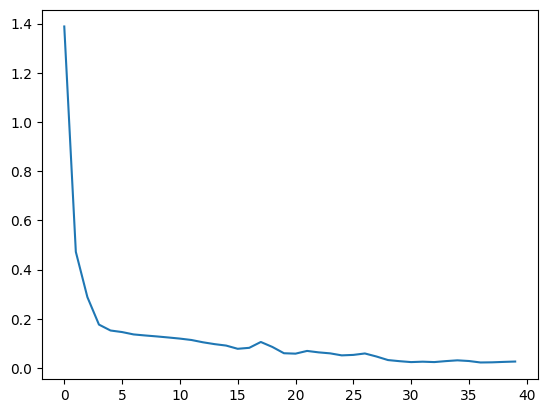

UnpicklingError: Weights only load failed. This file can still be loaded, to do so you have two options, [1mdo those steps only if you trust the source of the checkpoint[0m. 
	(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
	(2) Alternatively, to load with `weights_only=True` please check the recommended steps in the following error message.
	WeightsUnpickler error: Unsupported global: GLOBAL __main__.RNN was not an allowed global by default. Please use `torch.serialization.add_safe_globals([RNN])` or the `torch.serialization.safe_globals([RNN])` context manager to allowlist this global if you trust this class/function.

Check the documentation of torch.load to learn more about types accepted by default with weights_only https://pytorc

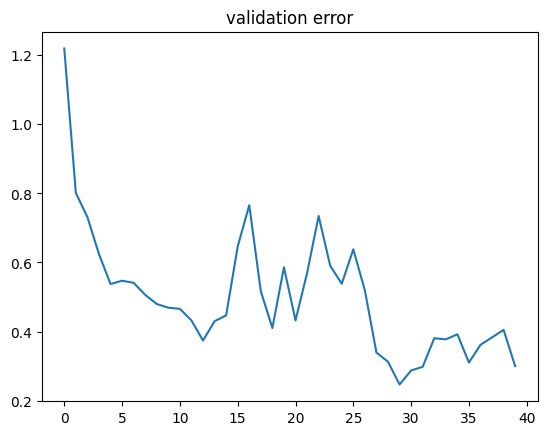

In [38]:
# RNN, number of grids < 16


num_grids_RNN_list2 = np.array([6, 8, 12])+1#np.arange(24,102,6, dtype=int)+1

rnnfunc_RNN_list2 = []
fit_window_train_RNN_list2, fit_window_test_RNN_list2 = [], []
fit_L2_err_train_RNN_list2, fit_L2_err_test_RNN_list2 = [], []
fit_L1_err_train_RNN_list2, fit_L1_err_test_RNN_list2 = [], []

fit_L2_err_train_RNN_mean_list2, fit_L2_err_test_RNN_mean_list2 = [], []
fit_L2_err_train_RNN_std_list2, fit_L2_err_test_RNN_std_list2 = [], []

pred_window_train_RNN_list2, pred_window_test_RNN_list2 = [], []
pred_window_train_RNN_list2_pre, pred_window_test_RNN_list2_pre = [], []
pred_L2_err_train_RNN_list2, pred_L2_err_test_RNN_list2 = [], []
pred_L1_err_train_RNN_list2, pred_L1_err_test_RNN_list2 = [], []

pred_L2_err_train_RNN_mean_list2, pred_L2_err_test_RNN_mean_list2 = [], []
pred_L2_err_train_RNN_std_list2, pred_L2_err_test_RNN_std_list2 = [], []

rng = np.random.default_rng()

batch_size = 64#128
verbose = 2
buffer_start_steps = 2

t1 = time.time()
index = np.arange(num_fine_grid+1)
for i, num_grids in enumerate(num_grids_RNN_list2):
    print('\n----------------------------------------------------------------\n')
    print('\nnon-adaptive method, number of grids = %d\n' % num_grids)
    index1 = np.round(np.arange(num_grids-1) * num_fine_grid/(num_grids-1))
    index1 = np.concatenate(([index1[0]]*buffer_start_steps, index1, [num_fine_grid]))

    print('train models:\n')

    rnn1_list = []
    fit_window_train1_list, fit_window_test1_list = [], []
    fit_L2_err_train1_list, fit_L2_err_test1_list = [], []
    fit_L1_err_train1_list, fit_L1_err_test1_list = [], []

    pred_window_train1_list, pred_window_test1_list = [], []
    pred_window_train1_list_pre, pred_window_test1_list_pre = [], []
    pred_L2_err_train1_list, pred_L2_err_test1_list = [], []
    pred_L1_err_train1_list, pred_L1_err_test1_list = [], []

    rep = 0
    while rep <= num_rep-1:

        train_windows0 = train_windows0_list[rep]
        train_ts0 = train_ts0_list[rep]
        test_windows0 = test_windows0_list[rep]
        test_ts0 = test_ts0_list[rep]

        train_ts1 = torch.tensor(np.linspace(train_ts0[:,0], train_ts0[:,-1], num_grids).T)
        train_ts1 = torch.concat((train_ts1[:,0].reshape(train_ts0.shape[0],1).repeat(1,buffer_start_steps),
                                train_ts1),axis=1)
        train_windows1 = interpolate_window(train_windows0, train_ts0, train_ts1, 'cubic')

        if buffer_start_steps > 0:
            deltat = train_ts1[0][-1] - train_ts1[0][-2]
            train_ts1[:,:buffer_start_steps] = (train_ts1[:,:buffer_start_steps] +
                                                torch.arange(-deltat*buffer_start_steps, 0, deltat))

        valid_index = np.sort(npr.choice(train_windows0.shape[0], 50, replace=False))
        valid_windows0 = train_windows0[valid_index,:,:]
        valid_ts0 = train_ts0[valid_index,:]

        train_index = np.delete(np.arange(train_windows0.shape[0]), valid_index)

        train_loader1 = torch.utils.data.DataLoader(
            MyDataset(train_windows=train_windows1[train_index,:,:], train_ts=train_ts1[train_index,:]),
            shuffle=True, batch_size=batch_size) # rescale the data

        input_steps1 = train_windows1.shape[1]

        print('\n------the %d-th replica:--------' % (rep+1))
        flag, rnn1 = train_RNN(train_loader1, input_steps1, valid_windows0, valid_ts0, num_grids, verbose,
                                n_iter=n_iter, thres1=4e2, n_latent=n_latent, obs_dim=obs_dim, time_scale=time_scale)
        if not flag:
            continue
        else:
            rep += 1

        print('\nfitting error of training data:')
        fit_window_train1, fit_L2_err_train1, fit_L1_err_train1 = fit_RNN_grids(
            rnn1, train_windows0, train_ts0, num_grids, buffer_start_steps=buffer_start_steps,
            n_latent=n_latent, obs_dim=obs_dim)
        print('\nfitting error of testing data:')
        fit_window_test1, fit_L2_err_test1, fit_L1_err_test1 = fit_RNN_grids(
            rnn1, test_windows0, test_ts0, num_grids, buffer_start_steps=buffer_start_steps,
            n_latent=n_latent, obs_dim=obs_dim)


        rnn1_list.append((copy.deepcopy(rnn1)))

        fit_L2_err_train1_list.append(fit_L2_err_train1)
        fit_L2_err_test1_list.append(fit_L2_err_test1)
        fit_L1_err_train1_list.append(fit_L1_err_train1)
        fit_L1_err_test1_list.append(fit_L1_err_test1)
        fit_window_train1_list.append(fit_window_train1)
        fit_window_test1_list.append(fit_window_test1)

        print('\npredicting error of training data:')
        pred_window_train1_pre, pred_window_train1, pred_L2_err_train1, pred_L1_err_train1 = pred_RNN_grids(
            rnn1, train_windows0, train_ts0, num_grids, buffer_start_steps=buffer_start_steps,
            n_latent=n_latent, obs_dim=obs_dim)
        print('\npredicting error of testing data:')
        pred_window_test1_pre, pred_window_test1, pred_L2_err_test1, pred_L1_err_test1 = pred_RNN_grids(
            rnn1, test_windows0, test_ts0, num_grids, buffer_start_steps=buffer_start_steps,
            n_latent=n_latent, obs_dim=obs_dim)

        pred_L2_err_train1_list.append(pred_L2_err_train1)
        pred_L2_err_test1_list.append(pred_L2_err_test1)
        pred_L1_err_train1_list.append(pred_L1_err_train1)
        pred_L1_err_test1_list.append(pred_L1_err_test1)
        pred_window_train1_list.append(pred_window_train1)
        pred_window_test1_list.append(pred_window_test1)
        pred_window_train1_list_pre.append(pred_window_train1_pre)
        pred_window_test1_list_pre.append(pred_window_test1_pre)


    rnnfunc_RNN_list2.append(rnn1_list)

    fit_window_train_RNN_list2.append(fit_window_train1_list)
    fit_window_test_RNN_list2.append(fit_window_test1_list)
    fit_L2_err_train_RNN_list2.append(fit_L2_err_train1_list)
    fit_L2_err_test_RNN_list2.append(fit_L2_err_test1_list)
    fit_L1_err_train_RNN_list2.append(fit_L1_err_train1_list)
    fit_L1_err_test_RNN_list2.append(fit_L1_err_test1_list)

    fit_L2_err_train_ave = np.mean(torch.stack(fit_L2_err_train1_list).numpy(),axis=(1,))
    fit_L2_err_test_ave = np.mean(torch.stack(fit_L2_err_test1_list).numpy(),axis=(1,))
    fit_L2_err_train_RNN_mean_list2.append(np.mean(fit_L2_err_train_ave))
    fit_L2_err_train_RNN_std_list2.append(np.std(fit_L2_err_train_ave))
    fit_L2_err_test_RNN_mean_list2.append(np.mean(fit_L2_err_test_ave))
    fit_L2_err_test_RNN_std_list2.append(np.std(fit_L2_err_test_ave))

    print('\nL2 fitting error of training data: mean = %.2e, std = %.2e' % (np.mean(fit_L2_err_train_ave),
                                                                         np.std(fit_L2_err_train_ave)))
    print('\nL2 fitting error of testing data: mean = %.2e, std = %.2e' % (np.mean(fit_L2_err_test_ave),
                                                                         np.std(fit_L2_err_test_ave)))
    pred_window_train_RNN_list2.append(pred_window_train1_list)
    pred_window_test_RNN_list2.append(pred_window_test1_list)
    pred_window_train_RNN_list2_pre.append(pred_window_train1_list_pre)
    pred_window_test_RNN_list2_pre.append(pred_window_test1_list_pre)
    pred_L2_err_train_RNN_list2.append(pred_L2_err_train1_list)
    pred_L2_err_test_RNN_list2.append(pred_L2_err_test1_list)
    pred_L1_err_train_RNN_list2.append(pred_L1_err_train1_list)
    pred_L1_err_test_RNN_list2.append(pred_L1_err_test1_list)

    pred_L2_err_train_ave = np.mean(torch.stack(pred_L2_err_train1_list).numpy(),axis=(1,))
    pred_L2_err_test_ave = np.mean(torch.stack(pred_L2_err_test1_list).numpy(),axis=(1,))
    pred_L2_err_train_RNN_mean_list2.append(np.mean(pred_L2_err_train_ave))
    pred_L2_err_train_RNN_std_list2.append(np.std(pred_L2_err_train_ave))
    pred_L2_err_test_RNN_mean_list2.append(np.mean(pred_L2_err_test_ave))
    pred_L2_err_test_RNN_std_list2.append(np.std(pred_L2_err_test_ave))

    print('\nL2 predicting error of training data: mean = %.2e, std = %.2e' % (np.mean(pred_L2_err_train_ave),
                                                                         np.std(pred_L2_err_train_ave)))
    print('\nL2 predicting error of testing data: mean = %.2e, std = %.2e' % (np.mean(pred_L2_err_test_ave),
                                                                         np.std(pred_L2_err_test_ave)))

t2 = time.time()
print('training model takes %.2f s' % (t2-t1) )


In [39]:
# compute errors

pred_L2_err_test_RNN_list_mean_mat1 = np.zeros((num_rep, len(num_grids_RNN_list1)))

for i in range(len(num_grids_RNN_list1)):
    pred_L2_err_test_RNN_list_mean_mat1[:,i] = torch.stack(pred_L2_err_test_RNN_list1[i]).mean(axis=(1,)).numpy()

pred_L2_err_test_RNN_list_mean_mat2 = np.zeros((num_rep, len(num_grids_RNN_list2)))

for i in range(len(num_grids_RNN_list2)):
    pred_L2_err_test_RNN_list_mean_mat2[:,i] = torch.stack(pred_L2_err_test_RNN_list2[i]).mean(axis=(1,)).numpy()



IndexError: list index out of range

# LSTM models


----------------------------------------------------------------


non-adaptive method, number of grids = 17

train models:



<ipython-input-40-9a58156710e5>:56: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  train_ts1 = torch.tensor(np.linspace(train_ts0[:,0], train_ts0[:,-1], num_grids).T)



------the 1-th replica:--------


<ipython-input-16-f93a6485bc5f>:69: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  test_ts2 = torch.tensor(np.linspace(ts_orig[:, 0], ts_orig[:, -1], num_grids).T)
<ipython-input-16-f93a6485bc5f>:119: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  pred_window_test2_temp[i, :, k] = torch.tensor(f(x2))  # [1:]
<ipython-input-16-f93a6485bc5f>:124: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  pred_L2_err_test2 = torch.mean(torch.sum((window_orig[:, -(ts_orig.shape[1] - 1) // 2:, :] - pred_window_test2) ** 2
<ipython-input-16-f93a6485bc5f>:126: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (po

the 1-th epoch, training loss = 1.6932e+00, remaining time = 0:00:51.305514
the 2-th epoch, training loss = 4.4308e-01, remaining time = 0:00:44.335411
the 3-th epoch, training loss = 1.7796e-01, remaining time = 0:00:36.740516
the 4-th epoch, training loss = 9.1198e-02, remaining time = 0:00:32.215682
the 5-th epoch, training loss = 5.3919e-02, remaining time = 0:00:29.482452
the 6-th epoch, training loss = 3.6088e-02, remaining time = 0:00:27.379207
the 7-th epoch, training loss = 2.6807e-02, remaining time = 0:00:25.677994
the 8-th epoch, training loss = 2.1722e-02, remaining time = 0:00:24.310907
the 9-th epoch, training loss = 1.7895e-02, remaining time = 0:00:23.093260
the 10-th epoch, training loss = 1.5160e-02, remaining time = 0:00:22.023440
the 11-th epoch, training loss = 1.3022e-02, remaining time = 0:00:20.908184
the 12-th epoch, training loss = 1.1185e-02, remaining time = 0:00:19.980043
the 13-th epoch, training loss = 9.7186e-03, remaining time = 0:00:19.297207
the 14-t

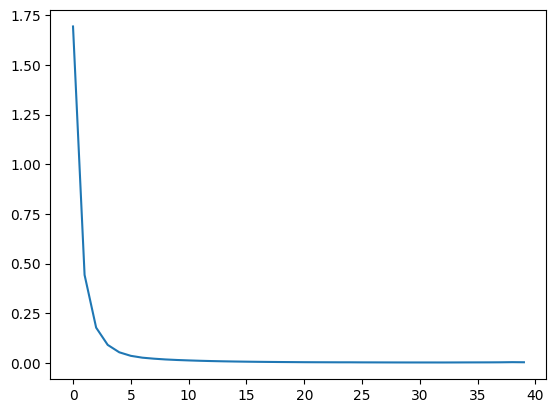

UnpicklingError: Weights only load failed. This file can still be loaded, to do so you have two options, [1mdo those steps only if you trust the source of the checkpoint[0m. 
	(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
	(2) Alternatively, to load with `weights_only=True` please check the recommended steps in the following error message.
	WeightsUnpickler error: Unsupported global: GLOBAL __main__.LSTM was not an allowed global by default. Please use `torch.serialization.add_safe_globals([LSTM])` or the `torch.serialization.safe_globals([LSTM])` context manager to allowlist this global if you trust this class/function.

Check the documentation of torch.load to learn more about types accepted by default with weights_only https://pyt

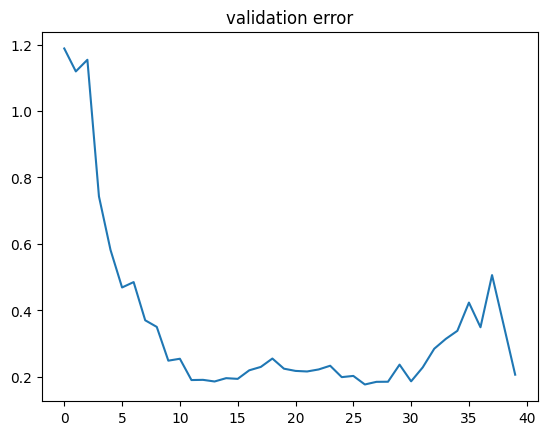

In [40]:
# LSTM, number of grids >= 16

num_grids_LSTM_list1 = np.arange(16,68,4, dtype=int)+1#np.arange(24,102,6, dtype=int)+1

lstmfunc_LSTM_list1 = []
fit_window_train_LSTM_list1, fit_window_test_LSTM_list1 = [], []
fit_L2_err_train_LSTM_list1, fit_L2_err_test_LSTM_list1 = [], []
fit_L1_err_train_LSTM_list1, fit_L1_err_test_LSTM_list1 = [], []

fit_L2_err_train_LSTM_mean_list1, fit_L2_err_test_LSTM_mean_list1 = [], []
fit_L2_err_train_LSTM_std_list1, fit_L2_err_test_LSTM_std_list1 = [], []

pred_window_train_LSTM_list1, pred_window_test_LSTM_list1 = [], []
pred_window_train_LSTM_list1_pre, pred_window_test_LSTM_list1_pre = [], []
pred_L2_err_train_LSTM_list1, pred_L2_err_test_LSTM_list1 = [], []
pred_L1_err_train_LSTM_list1, pred_L1_err_test_LSTM_list1 = [], []

pred_L2_err_train_LSTM_mean_list1, pred_L2_err_test_LSTM_mean_list1 = [], []
pred_L2_err_train_LSTM_std_list1, pred_L2_err_test_LSTM_std_list1 = [], []

rng = np.random.default_rng()


batch_size = 64#128
verbose = 2


t1 = time.time()
index = np.arange(num_fine_grid+1)
for i, num_grids in enumerate(num_grids_LSTM_list1):
    print('\n----------------------------------------------------------------\n')
    print('\nnon-adaptive method, number of grids = %d\n' % num_grids)
    index1 = np.round(np.arange(num_grids-1) * num_fine_grid/(num_grids-1))
    index1 = np.concatenate(([index1[0]]*buffer_start_steps, index1, [num_fine_grid]))

    print('train models:\n')

    LSTM1_list = []
    fit_window_train1_list, fit_window_test1_list = [], []
    fit_L2_err_train1_list, fit_L2_err_test1_list = [], []
    fit_L1_err_train1_list, fit_L1_err_test1_list = [], []

    pred_window_train1_list, pred_window_test1_list = [], []
    pred_window_train1_list_pre, pred_window_test1_list_pre = [], []
    pred_L2_err_train1_list, pred_L2_err_test1_list = [], []
    pred_L1_err_train1_list, pred_L1_err_test1_list = [], []

    rep = 0
    while rep <= num_rep-1:

        train_windows0 = train_windows0_list[rep]
        train_ts0 = train_ts0_list[rep]
        test_windows0 = test_windows0_list[rep]
        test_ts0 = test_ts0_list[rep]

        train_ts1 = torch.tensor(np.linspace(train_ts0[:,0], train_ts0[:,-1], num_grids).T)
        train_ts1 = torch.concat((train_ts1[:,0].reshape(train_ts0.shape[0],1).repeat(1,buffer_start_steps),
                                train_ts1),axis=1)
        train_windows1 = interpolate_window(train_windows0, train_ts0, train_ts1, 'cubic')

        if buffer_start_steps > 0:
            deltat = train_ts1[0][-1] - train_ts1[0][-2]
            train_ts1[:,:buffer_start_steps] = (train_ts1[:,:buffer_start_steps] +
                                                torch.arange(-deltat*buffer_start_steps, 0, deltat))

        valid_index = np.sort(npr.choice(train_windows0.shape[0], 50, replace=False))
        valid_windows0 = train_windows0[valid_index,:,:]
        valid_ts0 = train_ts0[valid_index,:]

        train_index = np.delete(np.arange(train_windows0.shape[0]), valid_index)

        train_loader1 = torch.utils.data.DataLoader(
            MyDataset(train_windows=train_windows1[train_index,:,:], train_ts=train_ts1[train_index,:]),
            shuffle=True, batch_size=batch_size,) # rescale the data

        input_steps1 = train_windows1.shape[1]

        print('\n------the %d-th replica:--------' % (rep+1))
        flag, lstm1 = train_LSTM(train_loader1, input_steps1, valid_windows0, valid_ts0, num_grids,
                                  verbose, n_iter=n_iter, thres1=6e2, thres2=5e2,
                                  n_latent=n_latent, obs_dim=obs_dim, time_scale=time_scale)
        if not flag:
            continue
        else:
            rep += 1

        print('\nfitting error of training data:')
        fit_window_train1, fit_L2_err_train1, fit_L1_err_train1 = fit_LSTM_grids(
            lstm1, train_windows0, train_ts0, num_grids, buffer_start_steps=buffer_start_steps,
            n_latent=n_latent, obs_dim=obs_dim)
        print('\nfitting error of testing data:')
        fit_window_test1, fit_L2_err_test1, fit_L1_err_test1 = fit_LSTM_grids(
            lstm1, test_windows0, test_ts0, num_grids, buffer_start_steps=buffer_start_steps,
            n_latent=n_latent, obs_dim=obs_dim)


        LSTM1_list.append(copy.deepcopy(lstm1))

        fit_L2_err_train1_list.append(fit_L2_err_train1)
        fit_L2_err_test1_list.append(fit_L2_err_test1)
        fit_L1_err_train1_list.append(fit_L1_err_train1)
        fit_L1_err_test1_list.append(fit_L1_err_test1)
        fit_window_train1_list.append(fit_window_train1)
        fit_window_test1_list.append(fit_window_test1)

        print('\npredicting error of training data:')
        pred_window_train1_pre, pred_window_train1, pred_L2_err_train1, pred_L1_err_train1 = pred_LSTM_grids(
            lstm1, train_windows0, train_ts0, num_grids, buffer_start_steps=buffer_start_steps,
            n_latent=n_latent, obs_dim=obs_dim)
        print('\npredicting error of testing data:')
        pred_window_test1_pre, pred_window_test1, pred_L2_err_test1, pred_L1_err_test1 = pred_LSTM_grids(
            lstm1, test_windows0, test_ts0, num_grids, buffer_start_steps=buffer_start_steps,
            n_latent=n_latent, obs_dim=obs_dim)

        pred_L2_err_train1_list.append(pred_L2_err_train1)
        pred_L2_err_test1_list.append(pred_L2_err_test1)
        pred_L1_err_train1_list.append(pred_L1_err_train1)
        pred_L1_err_test1_list.append(pred_L1_err_test1)
        pred_window_train1_list.append(pred_window_train1)
        pred_window_test1_list.append(pred_window_test1)
        pred_window_train1_list_pre.append(pred_window_train1_pre)
        pred_window_test1_list_pre.append(pred_window_test1_pre)

    lstmfunc_LSTM_list1.append(LSTM1_list)

    fit_window_train_LSTM_list1.append(fit_window_train1_list)
    fit_window_test_LSTM_list1.append(fit_window_test1_list)
    fit_L2_err_train_LSTM_list1.append(fit_L2_err_train1_list)
    fit_L2_err_test_LSTM_list1.append(fit_L2_err_test1_list)
    fit_L1_err_train_LSTM_list1.append(fit_L1_err_train1_list)
    fit_L1_err_test_LSTM_list1.append(fit_L1_err_test1_list)

    fit_L2_err_train_ave = np.mean(torch.stack(fit_L2_err_train1_list).numpy(),axis=(1,))
    fit_L2_err_test_ave = np.mean(torch.stack(fit_L2_err_test1_list).numpy(),axis=(1,))
    fit_L2_err_train_LSTM_mean_list1.append(np.mean(fit_L2_err_train_ave))
    fit_L2_err_train_LSTM_std_list1.append(np.std(fit_L2_err_train_ave))
    fit_L2_err_test_LSTM_mean_list1.append(np.mean(fit_L2_err_test_ave))
    fit_L2_err_test_LSTM_std_list1.append(np.std(fit_L2_err_test_ave))

    print('\nL2 fitting error of training data: mean = %.2e, std = %.2e' % (np.mean(fit_L2_err_train_ave),
                                                                         np.std(fit_L2_err_train_ave)))
    print('\nL2 fitting error of testing data: mean = %.2e, std = %.2e' % (np.mean(fit_L2_err_test_ave),
                                                                         np.std(fit_L2_err_test_ave)))

    pred_window_train_LSTM_list1.append(pred_window_train1_list)
    pred_window_test_LSTM_list1.append(pred_window_test1_list)
    pred_window_train_LSTM_list1_pre.append(pred_window_train1_list_pre)
    pred_window_test_LSTM_list1_pre.append(pred_window_test1_list_pre)
    pred_L2_err_train_LSTM_list1.append(pred_L2_err_train1_list)
    pred_L2_err_test_LSTM_list1.append(pred_L2_err_test1_list)
    pred_L1_err_train_LSTM_list1.append(pred_L1_err_train1_list)
    pred_L1_err_test_LSTM_list1.append(pred_L1_err_test1_list)

    pred_L2_err_train_ave = np.mean(torch.stack(pred_L2_err_train1_list).numpy(),axis=(1,))
    pred_L2_err_test_ave = np.mean(torch.stack(pred_L2_err_test1_list).numpy(),axis=(1,))
    pred_L2_err_train_LSTM_mean_list1.append(np.mean(pred_L2_err_train_ave))
    pred_L2_err_train_LSTM_std_list1.append(np.std(pred_L2_err_train_ave))
    pred_L2_err_test_LSTM_mean_list1.append(np.mean(pred_L2_err_test_ave))
    pred_L2_err_test_LSTM_std_list1.append(np.std(pred_L2_err_test_ave))

    print('\nL2 predicting error of training data: mean = %.2e, std = %.2e' % (np.mean(pred_L2_err_train_ave),
                                                                         np.std(pred_L2_err_train_ave)))
    print('\nL2 predicting error of testing data: mean = %.2e, std = %.2e' % (np.mean(pred_L2_err_test_ave),
                                                                         np.std(pred_L2_err_test_ave)))

t2 = time.time()
print('training model takes %.2f s' % (t2-t1) )



----------------------------------------------------------------


non-adaptive method, number of grids = 7

train models:



<ipython-input-41-71c4f22dbe7b>:56: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  train_ts1 = torch.tensor(np.linspace(train_ts0[:,0], train_ts0[:,-1], num_grids).T)



------the 1-th replica:--------


<ipython-input-16-f93a6485bc5f>:69: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  test_ts2 = torch.tensor(np.linspace(ts_orig[:, 0], ts_orig[:, -1], num_grids).T)
<ipython-input-16-f93a6485bc5f>:119: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  pred_window_test2_temp[i, :, k] = torch.tensor(f(x2))  # [1:]
<ipython-input-16-f93a6485bc5f>:124: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  pred_L2_err_test2 = torch.mean(torch.sum((window_orig[:, -(ts_orig.shape[1] - 1) // 2:, :] - pred_window_test2) ** 2
<ipython-input-16-f93a6485bc5f>:126: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (po

the 1-th epoch, training loss = 2.1378e+00, remaining time = 0:00:17.705944
the 2-th epoch, training loss = 7.3937e-01, remaining time = 0:00:16.415250
the 3-th epoch, training loss = 3.7293e-01, remaining time = 0:00:15.358933
the 4-th epoch, training loss = 2.3615e-01, remaining time = 0:00:14.788113
the 5-th epoch, training loss = 1.8296e-01, remaining time = 0:00:13.827299
the 6-th epoch, training loss = 1.4399e-01, remaining time = 0:00:13.073763
the 7-th epoch, training loss = 1.1362e-01, remaining time = 0:00:12.598348
the 8-th epoch, training loss = 8.5590e-02, remaining time = 0:00:11.954018
the 9-th epoch, training loss = 6.8452e-02, remaining time = 0:00:11.406574
the 10-th epoch, training loss = 5.6502e-02, remaining time = 0:00:10.966488
the 11-th epoch, training loss = 4.6512e-02, remaining time = 0:00:10.507774
the 12-th epoch, training loss = 4.0498e-02, remaining time = 0:00:10.066537
the 13-th epoch, training loss = 3.6284e-02, remaining time = 0:00:09.690710
the 14-t

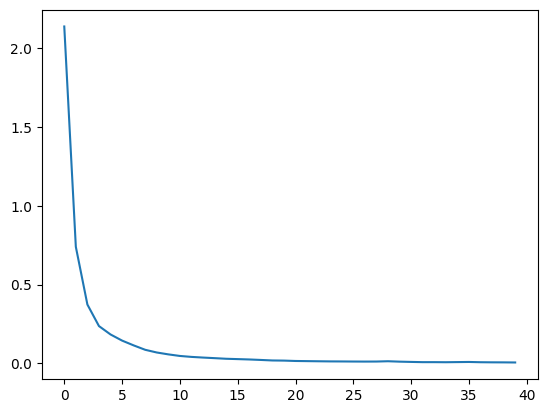

UnpicklingError: Weights only load failed. This file can still be loaded, to do so you have two options, [1mdo those steps only if you trust the source of the checkpoint[0m. 
	(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
	(2) Alternatively, to load with `weights_only=True` please check the recommended steps in the following error message.
	WeightsUnpickler error: Unsupported global: GLOBAL __main__.LSTM was not an allowed global by default. Please use `torch.serialization.add_safe_globals([LSTM])` or the `torch.serialization.safe_globals([LSTM])` context manager to allowlist this global if you trust this class/function.

Check the documentation of torch.load to learn more about types accepted by default with weights_only https://pyt

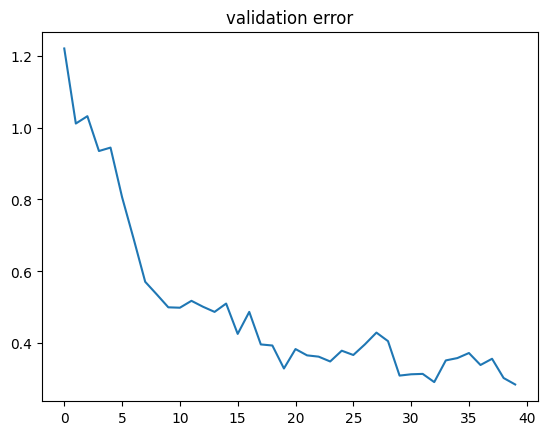

In [41]:
# LSTM, number of grids < 16

num_grids_LSTM_list2 = np.array([6,8,12])+1#np.arange(24,102,6, dtype=int)+1

lstmfunc_LSTM_list2 = []
fit_window_train_LSTM_list2, fit_window_test_LSTM_list2 = [], []
fit_L2_err_train_LSTM_list2, fit_L2_err_test_LSTM_list2 = [], []
fit_L1_err_train_LSTM_list2, fit_L1_err_test_LSTM_list2 = [], []

fit_L2_err_train_LSTM_mean_list2, fit_L2_err_test_LSTM_mean_list2 = [], []
fit_L2_err_train_LSTM_std_list2, fit_L2_err_test_LSTM_std_list2 = [], []

pred_window_train_LSTM_list2, pred_window_test_LSTM_list2 = [], []
pred_window_train_LSTM_list2_pre, pred_window_test_LSTM_list2_pre = [], []
pred_L2_err_train_LSTM_list2, pred_L2_err_test_LSTM_list2 = [], []
pred_L1_err_train_LSTM_list2, pred_L1_err_test_LSTM_list2 = [], []

pred_L2_err_train_LSTM_mean_list2, pred_L2_err_test_LSTM_mean_list2 = [], []
pred_L2_err_train_LSTM_std_list2, pred_L2_err_test_LSTM_std_list2 = [], []

rng = np.random.default_rng()


batch_size = 64#128
verbose = 2


t1 = time.time()
index = np.arange(num_fine_grid+1)
for i, num_grids in enumerate(num_grids_LSTM_list2):
    print('\n----------------------------------------------------------------\n')
    print('\nnon-adaptive method, number of grids = %d\n' % num_grids)
    index1 = np.round(np.arange(num_grids-1) * num_fine_grid/(num_grids-1))
    index1 = np.concatenate(([index1[0]]*buffer_start_steps, index1, [num_fine_grid]))

    print('train models:\n')

    LSTM1_list = []
    fit_window_train1_list, fit_window_test1_list = [], []
    fit_L2_err_train1_list, fit_L2_err_test1_list = [], []
    fit_L1_err_train1_list, fit_L1_err_test1_list = [], []

    pred_window_train1_list, pred_window_test1_list = [], []
    pred_window_train1_list_pre, pred_window_test1_list_pre = [], []
    pred_L2_err_train1_list, pred_L2_err_test1_list = [], []
    pred_L1_err_train1_list, pred_L1_err_test1_list = [], []

    rep = 0
    while rep <= num_rep-1:

        train_windows0 = train_windows0_list[rep]
        train_ts0 = train_ts0_list[rep]
        test_windows0 = test_windows0_list[rep]
        test_ts0 = test_ts0_list[rep]

        train_ts1 = torch.tensor(np.linspace(train_ts0[:,0], train_ts0[:,-1], num_grids).T)
        train_ts1 = torch.concat((train_ts1[:,0].reshape(train_ts0.shape[0],1).repeat(1,buffer_start_steps),
                                train_ts1),axis=1)
        train_windows1 = interpolate_window(train_windows0, train_ts0, train_ts1, 'cubic')

        if buffer_start_steps > 0:
            deltat = train_ts1[0][-1] - train_ts1[0][-2]
            train_ts1[:,:buffer_start_steps] = (train_ts1[:,:buffer_start_steps] +
                                                torch.arange(-deltat*buffer_start_steps, 0, deltat))

        valid_index = np.sort(npr.choice(train_windows0.shape[0], 50, replace=False))
        valid_windows0 = train_windows0[valid_index,:,:]
        valid_ts0 = train_ts0[valid_index,:]

        train_index = np.delete(np.arange(train_windows0.shape[0]), valid_index)

        train_loader1 = torch.utils.data.DataLoader(
            MyDataset(train_windows=train_windows1[train_index,:,:], train_ts=train_ts1[train_index,:]),
            shuffle=True, batch_size=batch_size,) # rescale the data

        input_steps1 = train_windows1.shape[1]

        print('\n------the %d-th replica:--------' % (rep+1))
        flag, lstm1 = train_LSTM(train_loader1, input_steps1, valid_windows0, valid_ts0, num_grids,
                                verbose, n_iter=n_iter, thres1=6e2, thres2=5e2,
                                n_latent=n_latent, obs_dim=obs_dim, time_scale=time_scale)
        if not flag:
            continue
        else:
            rep += 1

        print('\nfitting error of training data:')
        fit_window_train1, fit_L2_err_train1, fit_L1_err_train1 = fit_LSTM_grids(
            lstm1, train_windows0, train_ts0, num_grids, buffer_start_steps=buffer_start_steps,
            n_latent=n_latent, obs_dim=obs_dim)
        print('\nfitting error of testing data:')
        fit_window_test1, fit_L2_err_test1, fit_L1_err_test1 = fit_LSTM_grids(
            lstm1, test_windows0, test_ts0, num_grids, buffer_start_steps=buffer_start_steps,
            n_latent=n_latent, obs_dim=obs_dim)


        LSTM1_list.append(copy.deepcopy(lstm1))

        fit_L2_err_train1_list.append(fit_L2_err_train1)
        fit_L2_err_test1_list.append(fit_L2_err_test1)
        fit_L1_err_train1_list.append(fit_L1_err_train1)
        fit_L1_err_test1_list.append(fit_L1_err_test1)
        fit_window_train1_list.append(fit_window_train1)
        fit_window_test1_list.append(fit_window_test1)

        print('\npredicting error of training data:')
        pred_window_train1_pre, pred_window_train1, pred_L2_err_train1, pred_L1_err_train1 = pred_LSTM_grids(
            lstm1, train_windows0, train_ts0, num_grids, buffer_start_steps=buffer_start_steps,
            n_latent=n_latent, obs_dim=obs_dim)
        print('\npredicting error of testing data:')
        pred_window_test1_pre, pred_window_test1, pred_L2_err_test1, pred_L1_err_test1 = pred_LSTM_grids(
            lstm1, test_windows0, test_ts0, num_grids, buffer_start_steps=buffer_start_steps,
            n_latent=n_latent, obs_dim=obs_dim)

        pred_L2_err_train1_list.append(pred_L2_err_train1)
        pred_L2_err_test1_list.append(pred_L2_err_test1)
        pred_L1_err_train1_list.append(pred_L1_err_train1)
        pred_L1_err_test1_list.append(pred_L1_err_test1)
        pred_window_train1_list.append(pred_window_train1)
        pred_window_test1_list.append(pred_window_test1)
        pred_window_train1_list_pre.append(pred_window_train1_pre)
        pred_window_test1_list_pre.append(pred_window_test1_pre)

    lstmfunc_LSTM_list2.append(LSTM1_list)

    fit_window_train_LSTM_list2.append(fit_window_train1_list)
    fit_window_test_LSTM_list2.append(fit_window_test1_list)
    fit_L2_err_train_LSTM_list2.append(fit_L2_err_train1_list)
    fit_L2_err_test_LSTM_list2.append(fit_L2_err_test1_list)
    fit_L1_err_train_LSTM_list2.append(fit_L1_err_train1_list)
    fit_L1_err_test_LSTM_list2.append(fit_L1_err_test1_list)

    fit_L2_err_train_ave = np.mean(torch.stack(fit_L2_err_train1_list).numpy(),axis=(1,))
    fit_L2_err_test_ave = np.mean(torch.stack(fit_L2_err_test1_list).numpy(),axis=(1,))
    fit_L2_err_train_LSTM_mean_list2.append(np.mean(fit_L2_err_train_ave))
    fit_L2_err_train_LSTM_std_list2.append(np.std(fit_L2_err_train_ave))
    fit_L2_err_test_LSTM_mean_list2.append(np.mean(fit_L2_err_test_ave))
    fit_L2_err_test_LSTM_std_list2.append(np.std(fit_L2_err_test_ave))

    print('\nL2 fitting error of training data: mean = %.2e, std = %.2e' % (np.mean(fit_L2_err_train_ave),
                                                                         np.std(fit_L2_err_train_ave)))
    print('\nL2 fitting error of testing data: mean = %.2e, std = %.2e' % (np.mean(fit_L2_err_test_ave),
                                                                         np.std(fit_L2_err_test_ave)))

    pred_window_train_LSTM_list2.append(pred_window_train1_list)
    pred_window_test_LSTM_list2.append(pred_window_test1_list)
    pred_window_train_LSTM_list2_pre.append(pred_window_train1_list_pre)
    pred_window_test_LSTM_list2_pre.append(pred_window_test1_list_pre)
    pred_L2_err_train_LSTM_list2.append(pred_L2_err_train1_list)
    pred_L2_err_test_LSTM_list2.append(pred_L2_err_test1_list)
    pred_L1_err_train_LSTM_list2.append(pred_L1_err_train1_list)
    pred_L1_err_test_LSTM_list2.append(pred_L1_err_test1_list)

    pred_L2_err_train_ave = np.mean(torch.stack(pred_L2_err_train1_list).numpy(),axis=(1,))
    pred_L2_err_test_ave = np.mean(torch.stack(pred_L2_err_test1_list).numpy(),axis=(1,))
    pred_L2_err_train_LSTM_mean_list2.append(np.mean(pred_L2_err_train_ave))
    pred_L2_err_train_LSTM_std_list2.append(np.std(pred_L2_err_train_ave))
    pred_L2_err_test_LSTM_mean_list2.append(np.mean(pred_L2_err_test_ave))
    pred_L2_err_test_LSTM_std_list2.append(np.std(pred_L2_err_test_ave))

    print('\nL2 predicting error of training data: mean = %.2e, std = %.2e' % (np.mean(pred_L2_err_train_ave),
                                                                         np.std(pred_L2_err_train_ave)))
    print('\nL2 predicting error of testing data: mean = %.2e, std = %.2e' % (np.mean(pred_L2_err_test_ave),
                                                                         np.std(pred_L2_err_test_ave)))

t2 = time.time()
print('training model takes %.2f s' % (t2-t1) )


In [42]:
# compute errors

pred_L2_err_test_LSTM_list_mean_mat1 = np.zeros((num_rep, len(num_grids_LSTM_list1)))

for i in range(len(num_grids_LSTM_list1)):
    pred_L2_err_test_LSTM_list_mean_mat1[:,i] = torch.stack(pred_L2_err_test_LSTM_list1[i]).mean(axis=(1,)).numpy()


pred_L2_err_test_LSTM_list_mean_mat2 = np.zeros((num_rep, len(num_grids_LSTM_list2)))

for i in range(len(num_grids_LSTM_list2)):
    pred_L2_err_test_LSTM_list_mean_mat2[:,i] = torch.stack(pred_L2_err_test_LSTM_list2[i]).mean(axis=(1,)).numpy()


IndexError: list index out of range

# Plots

NameError: name 'pred_L2_err_test_non_adap_list_mean_mat2' is not defined

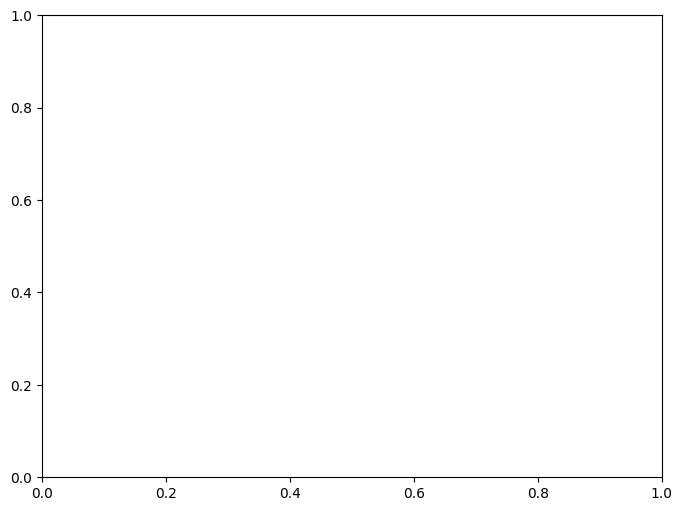

In [43]:
# box plot

alpha = 0.5
index1 = [0,1,2,3,4,5,6,7,8,9,10,11,12]
# plt.figure(figsize=(7,5))
fig, ax = plt.subplots(figsize=(8,6))
linewidth = 2

cols = ['tab:green'] * 13
xticks = np.concatenate((np.array(num_grids_non_adap_list2), np.array(num_grids_non_adap_list1)))
err_temp = np.concatenate((np.array(pred_L2_err_test_non_adap_list_mean_mat2), np.array(pred_L2_err_test_non_adap_list_mean_mat1)), axis=1)
bp = ax.boxplot(err_temp, positions=xticks,
           widths = 0.4, whis=0.5, whiskerprops={'color' : 'tab:green'},
                medianprops={'color' : 'tab:green', 'linewidth': 3},
                boxprops={'color' : 'tab:green'},
                flierprops={'markersize':0.01})
res = {key : [v.get_ydata() for v in value] for key, value in bp.items()}
ax.plot(xticks, np.array(res['medians'])[:,0], 'x-', color='tab:green',
        label='RNNODE', alpha=alpha, linewidth=linewidth)
for b, c in zip(bp['boxes'], cols):
    b.set_alpha(alpha)
print(np.array(res['medians'])[:,0])


cols = ['tab:red'] * 13
xticks = np.concatenate((np.array(num_grids_non_adap_list2), np.array(num_grids_non_adap_list1)))
err_temp = np.concatenate((np.array(pred_L2_err_test_adap_list_mean_mat2), np.array(pred_L2_err_test_adap_list_mean_mat1)), axis=1)
bp = ax.boxplot(err_temp, positions=xticks,
           widths = 0.4, whis=0.5, whiskerprops={'color' : 'tab:red'},
                medianprops={'color' : 'tab:red', 'linewidth': 3},
                boxprops={'color' : 'tab:red'},
                flierprops={'markersize':0.01})
res = {key : [v.get_ydata() for v in value] for key, value in bp.items()}
ax.plot(xticks, np.array(res['medians'])[:,0], 'x-', color='tab:red',
        label='RNN-ODE-Adap', alpha=alpha, linewidth=linewidth)
for b, c in zip(bp['boxes'], cols):
    b.set_alpha(alpha)


cols = ['tab:blue'] * 13
xticks = np.concatenate((np.array(num_grids_RNN_list2), np.array(num_grids_RNN_list1)))
err_temp = np.concatenate((np.array(pred_L2_err_test_RNN_list_mean_mat2), np.array(pred_L2_err_test_RNN_list_mean_mat1)), axis=1)
bp = ax.boxplot(err_temp, positions=xticks,
                 widths = 0.4, whis=0.01, whiskerprops={'color' : 'tab:blue'},
                 medianprops={'color' : 'tab:blue', 'linewidth': 3},
                 boxprops={'color' : 'tab:blue'},
                 flierprops={'markersize':0.01}
                )
res = {key : [v.get_ydata() for v in value] for key, value in bp.items()}
ax.plot(xticks, np.array(res['medians'])[:,0], 'x-', color='tab:blue',
        label='RNN', alpha=alpha, linewidth=linewidth)
for b, c in zip(bp['boxes'], cols):
    b.set_alpha(alpha)
print(np.array(res['medians'])[:,0])

cols = ['tab:orange'] * 13
xticks = np.concatenate((np.array(num_grids_LSTM_list2), np.array(num_grids_LSTM_list1)))
err_temp = np.concatenate((np.array(pred_L2_err_test_LSTM_list_mean_mat2), np.array(pred_L2_err_test_LSTM_list_mean_mat1)), axis=1)
bp = ax.boxplot(err_temp, positions=xticks,
                 widths = 0.4, whis=0.5, whiskerprops={'color' : 'tab:orange'},
                 medianprops={'color' : 'tab:orange', 'linewidth': 3},
                 boxprops={'color' : 'tab:orange'},
                 flierprops={'markersize':0.01}
                )
res = {key : [v.get_ydata() for v in value] for key, value in bp.items()}
ax.plot(xticks, np.array(res['medians'])[:,0], 'x-', color='tab:orange',
        label='LSTM', alpha=alpha, linewidth=linewidth)
for b, c in zip(bp['boxes'], cols):
    b.set_alpha(alpha)


xticks = np.concatenate((np.array(num_grids_non_adap_list2), np.array(num_grids_non_adap_list1)))
plt.xticks(xticks,
           list(map(str, xticks)))
plt.ylim([0, 0.4])
plt.xlabel('number of grids', fontsize=14)
plt.ylabel('MSE', fontsize=14)
plt.legend(fontsize=14)
plt.grid()
plt.suptitle('Spiral data: Testing Precition MSE vs. Complexity (boxplot)', fontsize=16)
# plt.savefig('spiral_error_boxplot.eps', format='eps', dpi=1000)

plt.show()



In [44]:
import torch
print(torch.__version__)

2.6.0+cu124
